In [87]:
import sys
import subprocess

# in case of numba installation error. could occur if numba and numpy version don't align... or could occur completely because of a cloud environment issue
# explicitly uninstalling ensures bad C-extension .so files are erased
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "numpy", "numba", "-y"])
# --only-binary :all: bypasses local compilation and uses low-RAM pre-built files
subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "--only-binary", ":all:", 
    "numpy>=2.3.0,<2.4.0", "numba>=0.62.0"
])

Found existing installation: numpy 2.3.5
Uninstalling numpy-2.3.5:
  Successfully uninstalled numpy-2.3.5
Found existing installation: numba 0.66.0
Uninstalling numba-0.66.0:
  Successfully uninstalled numba-0.66.0
  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached numba-0.66.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached numba-0.66.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires cf_xarray>=0.6.0, which is not installed.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.


0

In [88]:
import pandas as pd
import numba
import numpy as np
import os
import platform
import psutil
import json
import time
import tracemalloc
import csv
!pip install optuna
import optuna
from itertools import combinations
!pip install shap
import shap
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
!pip install lightgbm
from lightgbm import LGBMRegressor
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
!pip install xlrd
import xlrd
!pip install pyxlsb
import pyxlsb

Instructions are in READMEDATA.md in GitHub repo for manually pulling the four datasets below. The other two are scraped in this cell. 

This cell is unique to NASA Cyrocloud. If you are running this locally or on another cloud, make revisions where necessary!

Finding directory path and setting raw and conjoined dataset directories.

In [89]:
# automatically detects CryoCloud vs local environment
# and sets paths accordingly

IS_CRYOCLOUD = os.path.exists('/home/jovyan')  

if IS_CRYOCLOUD:
    BASE_DIR = '/home/jovyan/henry-hub-ng-forecasting'
else:
    BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

# printing the directory
print(f"Environment: {'CryoCloud (NASA)' if IS_CRYOCLOUD else 'Local'}")
    
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')
OUT_DIR  = os.path.join(BASE_DIR, 'data', 'processed')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)

Environment: CryoCloud (NASA)


Links for Henry Hub Natural Gas Spot Price and WTI Crude Oil Spot Price (Microsoft Excel)

Links for: 

National Oceanic and Atmospheric Administration (NOAA) - Heating and Cooling Degree Days

U.S. Energy Information Administration (EIA) - Weekly Natural Gas Storage Report (Natural Gas Working Storage Level & 5-Year Average)

Baker Hughes North America Rig Count

In [90]:
# data source paths
# FRED sources — fetched directly from URL (no download required)
HH_PATH  = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=WHHNGSP"
WTI_PATH = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"

# manual downloads
# see data/README.md for download instructions
NOAA_PATH     = os.path.join(DATA_DIR, "noaa_hdd_cdd_weekly (1).csv")
NGS_ARCH_PATH = os.path.join(DATA_DIR, "archngshistory (1).xls")
NGS_CURR_PATH = os.path.join(DATA_DIR, "ngshistory (2).xls")
BH_PATH       = os.path.join(DATA_DIR, "North America Rotary Rig Count (Jan 2000 - Mar 2024) (1).xlsb")
OUTPUT_PATH   = os.path.join(OUT_DIR,  "ng_dataset_final (21).csv")

# pre-flight check
manual_files = {
    'NOAA HDD/CDD':            NOAA_PATH,
    'EIA Storage Archive':     NGS_ARCH_PATH,
    'EIA Storage Current':     NGS_CURR_PATH,
    'Baker Hughes Rig Count':  BH_PATH,
}

Within the first function, the variable 'observation_date' is converted to a numeric date value, for both Henry Hub Natural Gas Spot Price and WTI Crude Oil Spot Price. This ensures consistency and interpretability for the model. 

In [91]:
# data loading functions 
def load_fred(url, value_col, date_col='observation_date'):
    """Load a FRED series directly from URL."""
    df = pd.read_csv(url, parse_dates=[date_col])
    df.columns = ['date', value_col]
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    df = df.dropna(subset=[value_col])
    df = df.set_index('date').sort_index()
    return df

# load all sources 
hh_df  = load_fred(HH_PATH,  value_col='hh_price')
wti_df = load_fred(WTI_PATH, value_col='wti_price')

Parsing thorugh all Excel datasets (which includes Natural Gas Working Storage Level & 5-Year Average and North America Rotary Rig Count) and ensuring all date columns are consistent and interpretable for the model. 

In [92]:
# looading excel data files
def load_excel(path, sheet=0, date_col='date', value_cols=None, skiprows=0):
    """Load an Excel or XLS file with flexible options."""
    ext = os.path.splitext(path)[1].lower()
    if ext == '.xlsb':
        df = pd.read_excel(path, sheet_name=sheet,
                           engine='pyxlsb', skiprows=skiprows)
    else:
        df = pd.read_excel(path, sheet_name=sheet, skiprows=skiprows)
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df = df.set_index(date_col).sort_index()
    if value_cols:
        df = df[value_cols]
    print(f"  Loaded {os.path.basename(path)}: {len(df)} obs")
    return df

For the NOAA weather data (Heating and Cooling Degree Days), all date data are organized chronologically. Also, the hdd (Heating Degree Days) and cdd (Cooling Degree Days) are both ensured to be numeric values for interpretability. 

In [93]:
# loading weather files 
def load_noaa(path):
    """Load NOAA HDD/CDD weekly CSV."""
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.set_index('date').sort_index()
    for col in ['hdd', 'cdd']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"  Loaded NOAA HDD/CDD: {len(df)} obs "
          f"({df.index.min().date()} → {df.index.max().date()})")
    return df

WTI Crude Oil Spot Price data are provided with daily granularity. However, for this study, weekly granularity will suffice. Therefore, only Saturday data values (2002 - 2024) are collected from the raw dataset. All other data are obviated. 

In [94]:
# resample WTI from daily to weekly friday frequency
wti_df = wti_df.resample('W-SAT').last().ffill()
all_present = all(os.path.exists(path) for path in manual_files.values())

Within the EIA datasets (for both Natural Gas Working Storage Level & 5-Year Average) large metadata headers block before the actual data starts. Within the archive dataset (5-year Average) the actual data begins at row 8. Within the current dataset (Working Storage Level) the actual data begins at row 7. Once these dataset locations are detected by the function, both 'date' and 'storage_bcf' are converted, respectively, to date/time and numeric values, interpretable for the models. Finally, both datasets are combined. 

In [95]:
# archive: header at row 7, data at row 8
# current: header at row 6, data at row 7
# total Lower 48 is always the last column.
def parse_eia_storage(path):
    ext = os.path.splitext(path)[1].lower()
    engine = 'xlrd' if ext == '.xls' else 'openpyxl'

    # detect header row by scanning for 'Week ending'
    df_raw = pd.read_excel(path, header=None, engine=engine)
    header_row = 0
    for i in range(15):
        row_vals = ' '.join([str(v) for v in df_raw.iloc[i].values if pd.notna(v)])
        if 'Week ending' in row_vals:
            header_row = i
            break

    df = pd.read_excel(path, skiprows=header_row, header=0, engine=engine)

    # date = first column, storage = last column (Total Lower 48)
    df = df.iloc[:, [0, -1]].copy()
    df.columns = ['date', 'storage_bcf']

    df['date']        = pd.to_datetime(df['date'], errors='coerce')
    df['storage_bcf'] = pd.to_numeric(df['storage_bcf'], errors='coerce')

    df = df.dropna(subset=['date', 'storage_bcf'])
    df = df.set_index('date').sort_index()

    print(f"  {len(df)} obs "
          f"({df.index.min().date()} → {df.index.max().date()})")
    return df

# Reload both with auto-detecting parser
ngs_arch_df = parse_eia_storage(NGS_ARCH_PATH)
ngs_curr_df = parse_eia_storage(NGS_CURR_PATH)

  1141 obs (1993-12-31 → 2015-11-06)
  853 obs (2010-01-01 → 2026-05-01)


Parsing Baker Hughes North America Rig Count sheet to convert dates from Excel serial numbers to numerical, interpretable date values. Planning to keep date and gas columns only. 

In [96]:
def parse_baker_hughes(path):
    df = pd.read_excel(path, engine='pyxlsb',
                       sheet_name='US Oil & Gas Split',
                       skiprows=6, header=0)

    df = df.iloc[:, [0, 2]].copy()
    df.columns = ['date', 'rig_count']

    df['date'] = pd.to_datetime(
        df['date'].apply(
            lambda x: pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(x))
            if pd.notna(x) and str(x).strip() not in ['', 'nan', 'Date']
            else pd.NaT
        ),
        errors='coerce'
    )

    df['rig_count'] = pd.to_numeric(df['rig_count'], errors='coerce')

    df = df.dropna(subset=['date', 'rig_count'])
    df = df.set_index('date').sort_index()

    print(f"  Parsed Baker Hughes: {len(df)} obs "
          f"({df.index.min().date()} → {df.index.max().date()})")
    print(f"  Rig count range: {df['rig_count'].min():.0f} – "
          f"{df['rig_count'].max():.0f}")
    return df

bh_df = parse_baker_hughes(BH_PATH)

  Parsed Baker Hughes: 1916 obs (1987-07-17 → 2024-03-28)
  Rig count range: 68 – 1606


Although Du et al. parses monthly data, the granularity of this dataset will be weekly. The goal is to interpret weekly spot price behavior shifts

Checking for all files prior to merging. Once merge occurs, the derived features (similar to Du et al.) are calculated manually. 
The reason behind forcing the data to begin in 2002 is due to Henry Hub Spot Price weekly survey beginning in March 2002. All data are aligned to the target variable. 
The final dataset is saved

In [97]:
# ensuring all filles are present to merge! otherwise data structure will not match du et al.
if all_present:
    noaa_df = load_noaa(NOAA_PATH)
    ngs_arch_df = parse_eia_storage(NGS_ARCH_PATH)
    ngs_curr_df = parse_eia_storage(NGS_CURR_PATH)
    bh_df       = parse_baker_hughes(BH_PATH)

    # combine — current file takes priority on overlapping dates
    ngs_df = pd.concat([ngs_arch_df, ngs_curr_df]).sort_index()
    ngs_df = ngs_df[~ngs_df.index.duplicated(keep='last')]
else:
    print("missing files. check links.")
    sys.exit(0)

# normalize all indices to saturday
def normalize_to_saturday(df):
    df = df.copy()
    df.index = df.index + pd.to_timedelta((5 - df.index.dayofweek) % 7, unit='D')
    df = df[~df.index.duplicated(keep='last')]
    return df

hh_df   = normalize_to_saturday(hh_df)
wti_df  = normalize_to_saturday(wti_df)
noaa_df = normalize_to_saturday(noaa_df)
ngs_df  = normalize_to_saturday(ngs_df)
bh_df   = normalize_to_saturday(bh_df)

# merging and filtering data period to begin on 
df = pd.concat([hh_df, wti_df, noaa_df, ngs_df, bh_df], axis=1, join='inner')
df = df[df.index >= '2002-12-28']

# derived features
df['storage_5yr_avg'] = (
    df['storage_bcf']
    .rolling(window=260, min_periods=52)
    .mean()
)

df['storage_vs_5yr'] = df['storage_bcf'] - df['storage_5yr_avg']
df['storage_chg']    = df['storage_bcf'].diff(1)
df['rig_lag4']       = df['rig_count'].shift(4)
df['lag_1']          = df['hh_price'].shift(1)
df['lag_2']          = df['hh_price'].shift(2)
df['lag_4']          = df['hh_price'].shift(4)
df['lag_52']         = df['hh_price'].shift(52)

df = df.dropna()
df.index = pd.to_datetime(df.index)

# saving
df.to_csv(OUTPUT_PATH)

print(f"\nDescriptive Statistics:")
print(df.describe().round(2).to_string()) 

  Loaded NOAA HDD/CDD: 1306 obs (2000-01-01 → 2025-01-04)
  1141 obs (1993-12-31 → 2015-11-06)
  853 obs (2010-01-01 → 2026-05-01)
  Parsed Baker Hughes: 1916 obs (1987-07-17 → 2024-03-28)
  Rig count range: 68 – 1606

Descriptive Statistics:
       hh_price  wti_price      hdd      cdd  storage_bcf  rig_count  storage_5yr_avg  storage_vs_5yr  storage_chg  rig_lag4    lag_1    lag_2    lag_4   lag_52
count   1056.00    1056.00  1056.00  1056.00      1056.00    1056.00          1056.00         1056.00      1056.00   1056.00  1056.00  1056.00  1056.00  1056.00
mean       4.43      70.23    80.63    25.78      2658.66     581.64          2562.29           96.36        -0.42    584.84     4.44     4.44     4.45     4.58
std        2.30      22.43    74.04    29.77       749.55     496.86           267.08          736.32        97.07    496.55     2.29     2.29     2.29     2.27
min        1.40      15.48     0.00     0.00       822.00      68.00          1785.84        -1992.64      -359.0

Exploratory Data Analysis

Analyzing if any data are missing from the dataset

In [98]:
# matching the display names to the variables
# calculating missing rate to address potential 'NaN' values
variables = [
    'hh_price', 'hdd', 'cdd',
    'storage_bcf', 'storage_chg', 'storage_vs_5yr',
    'rig_count', 'rig_lag4',
    'wti_price',
    'lag_1', 'lag_2', 'lag_4', 'lag_52'
]

display_names = {
    'hh_price'       : 'HH Spot Price',
    'hdd'            : 'HDD',
    'cdd'            : 'CDD',
    'storage_bcf'    : 'Storage Level',
    'storage_chg'    : 'Storage Chg (Wk)',
    'storage_vs_5yr' : 'Storage vs 5yr Avg',
    'rig_count'      : 'Rig Count',
    'rig_lag4'       : 'Rig Count (Lag-4)',
    'wti_price'      : 'WTI Price',
    'lag_1'          : 'Lag-1 Price',
    'lag_2'          : 'Lag-2 Price',
    'lag_4'          : 'Lag-4 Price',
    'lag_52'         : 'Lag-52 Price',
}

Table 1: Missing Rate — Natural Gas Forecasting Dataset
Total observations: 1056

Variable                # Missing   Missing Rate Source                   
---------------------------------------------------------------------------
  HH Spot Price                 0             0% FRED / EIA               
  HDD                           0             0% NOAA CPC                 
  CDD                           0             0% NOAA CPC                 
  Storage Level                 0             0% EIA                      
  Storage Chg (Wk)              0             0% EIA (derived)            
  Storage vs 5yr Avg            0             0% EIA (derived)            
  Rig Count                     0             0% Baker Hughes             
  Rig Count (Lag-4)             0             0% Baker Hughes (derived)   
  WTI Price                     0             0% FRED / EIA               
  Lag-1 Price                   0             0% FRED (derived)           
  Lag-2 Price    

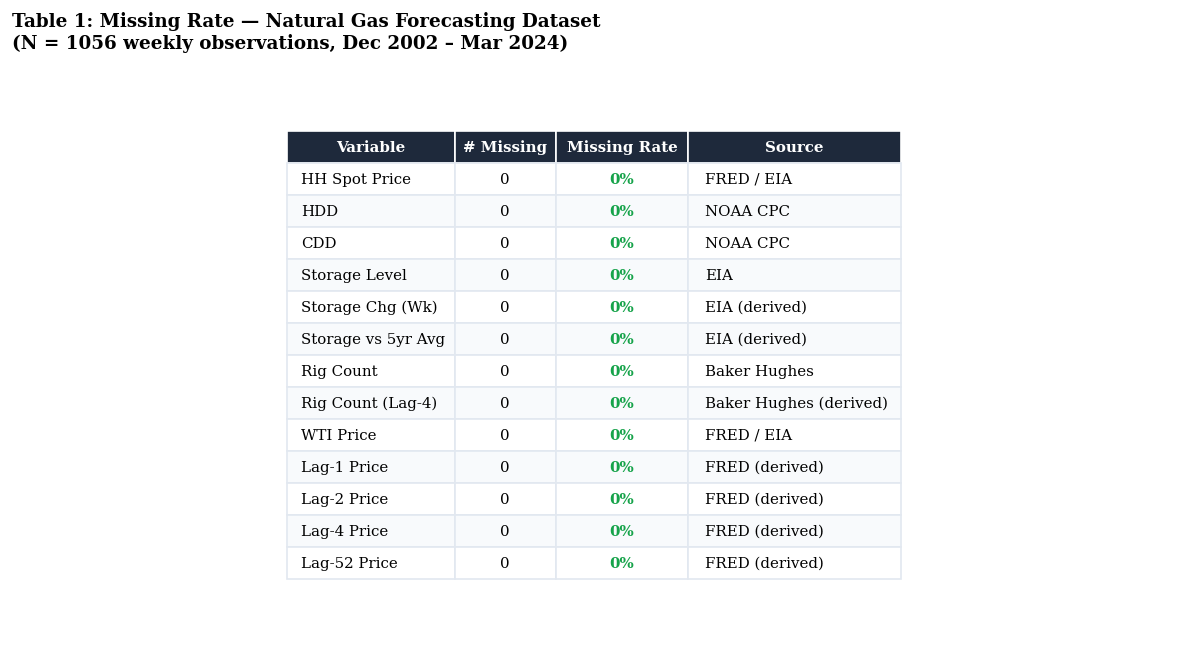

In [99]:
n = len(df)
rows = []
for col in variables:
    missing = df[col].isna().sum()
    rate    = missing / n
    rows.append({
        'Variable'    : display_names[col],
        '# Missing'   : missing,
        'Missing Rate': f'{rate:.0%}',
        'Type'        : df[col].dtype,
        'Source'      : {
            'hh_price'       : 'FRED / EIA',
            'hdd'            : 'NOAA CPC',
            'cdd'            : 'NOAA CPC',
            'storage_bcf'    : 'EIA',
            'storage_chg'    : 'EIA (derived)',
            'storage_vs_5yr' : 'EIA (derived)',
            'rig_count'      : 'Baker Hughes',
            'rig_lag4'       : 'Baker Hughes (derived)',
            'wti_price'      : 'FRED / EIA',
            'lag_1'          : 'FRED (derived)',
            'lag_2'          : 'FRED (derived)',
            'lag_4'          : 'FRED (derived)',
            'lag_52'         : 'FRED (derived)',
        }[col]
    })

table_df = pd.DataFrame(rows)

print("Table 1: Missing Rate — Natural Gas Forecasting Dataset")
print(f"Total observations: {n}")
print()
print(f"{'Variable':<22} {'# Missing':>10} {'Missing Rate':>14} {'Source':<25}")
print("-" * 75)
for _, row in table_df.iterrows():
    print(f"  {row['Variable']:<20} {row['# Missing']:>10} {row['Missing Rate']:>14} {row['Source']:<25}")
print("-" * 75)
print(f"  {'Total':.<20} {table_df['# Missing'].sum():>10} {'—':>14}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis('off')

col_labels = ['Variable', '# Missing', 'Missing Rate', 'Source']
cell_data  = [
    [row['Variable'], row['# Missing'], row['Missing Rate'], row['Source']]
    for _, row in table_df.iterrows()
]

tbl = ax.table(
    cellText   = cell_data,
    colLabels  = col_labels,
    cellLoc    = 'center',
    loc        = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.45)

# style header row
for col_idx in range(len(col_labels)):
    cell = tbl[0, col_idx]
    cell.set_facecolor('#1e293b')
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

# style data rows — alternate shading
for row_idx in range(1, len(cell_data) + 1):
    for col_idx in range(len(col_labels)):
        cell = tbl[row_idx, col_idx]
        cell.set_edgecolor('#e2e8f0')
        if row_idx % 2 == 0:
            cell.set_facecolor('#f8fafc')
        else:
            cell.set_facecolor('white')

        if col_idx in [0, 3]:
            cell.get_text().set_ha('left')
            cell.PAD = 0.08

        if col_idx == 2:
            cell.set_text_props(color='#16a34a', fontweight='bold')

# column widths
tbl.auto_set_column_width([0, 1, 2, 3])

ax.set_title('Table 1: Missing Rate — Natural Gas Forecasting Dataset\n'
             f'(N = {n} weekly observations, Dec 2002 – Mar 2024)',
             fontsize=11, fontweight='bold', pad=16, loc='left')

plt.tight_layout()
plt.savefig('table1_missing_rate.png', bbox_inches='tight', dpi=150)
plt.show()

Quantifying the outliers per feature

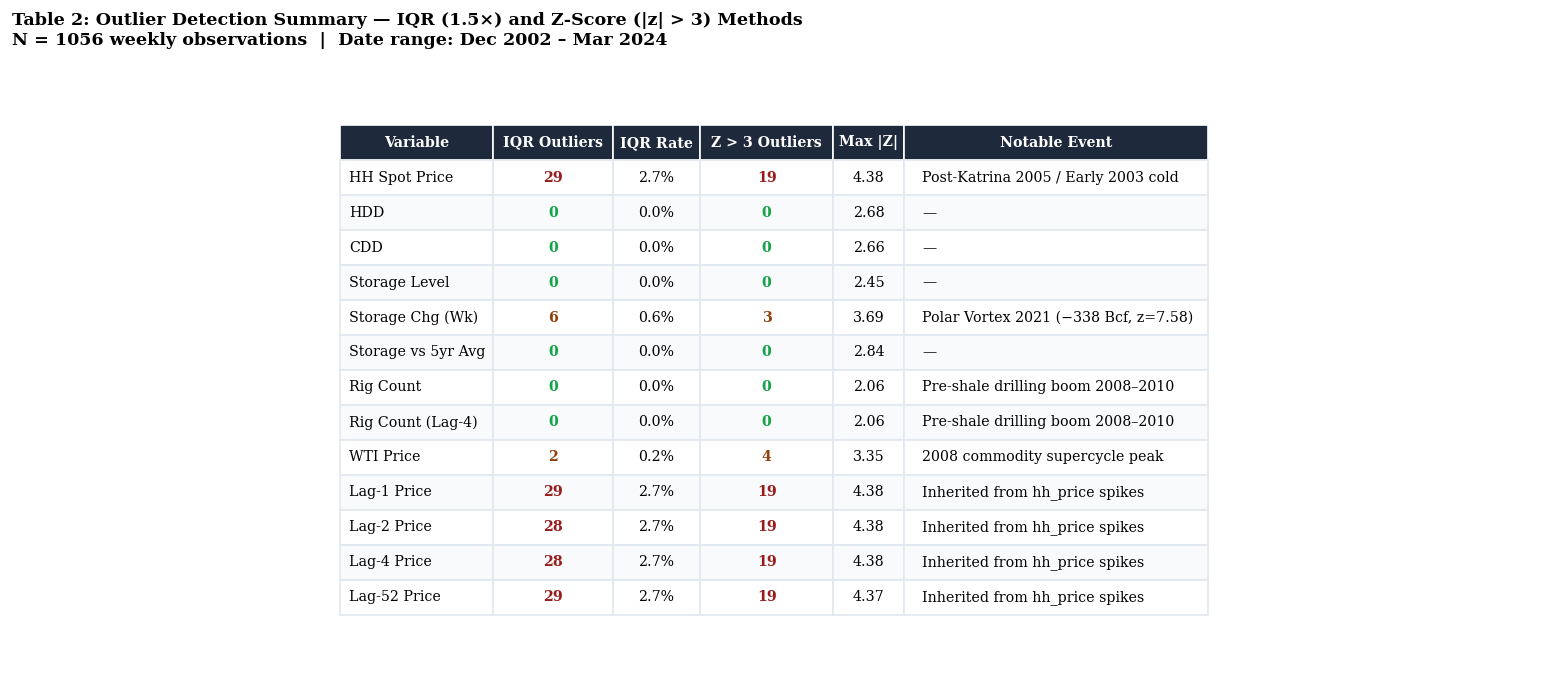

In [100]:
event = {
    'hh_price'    : 'Post-Katrina 2005 / Early 2003 cold',
    'storage_chg' : 'Polar Vortex 2021 (−338 Bcf, z=7.58)',
    'rig_count'   : 'Pre-shale drilling boom 2008–2010',
    'rig_lag4'    : 'Pre-shale drilling boom 2008–2010',
    'wti_price'   : '2008 commodity supercycle peak',
    'lag_1'       : 'Inherited from hh_price spikes',
    'lag_2'       : 'Inherited from hh_price spikes',
    'lag_4'       : 'Inherited from hh_price spikes',
    'lag_52'      : 'Inherited from hh_price spikes',
}

n = len(df)
rows = []

for col in variables:
    # IQR method
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_out = df[(df[col] < lower) | (df[col] > upper)]
    iqr_n   = len(iqr_out)
    iqr_pct = f'{100 * iqr_n / n:.1f}%'

    # z-score method
    z = (df[col] - df[col].mean()) / df[col].std()
    z_out  = df[z.abs() > 3]
    z_n    = len(z_out)
    z_max  = f'{z.abs().max():.2f}'

    rows.append({
        'Variable'         : display_names[col],
        'IQR Outliers'     : iqr_n,
        'IQR Rate'         : iqr_pct,
        'Z > 3 Outliers'   : z_n,
        'Max |Z|'          : z_max,
        'Notable Event'    : event.get(col, '—'),
    })

table_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.axis('off')

col_labels = ['Variable', 'IQR Outliers', 'IQR Rate', 'Z > 3 Outliers', 'Max |Z|', 'Notable Event']
cell_data  = [list(row) for row in table_df.values]

tbl = ax.table(
    cellText  = cell_data,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.55)

for col_idx in range(len(col_labels)):
    cell = tbl[0, col_idx]
    cell.set_facecolor('#1e293b')
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

for row_idx in range(1, len(cell_data) + 1):
    iqr_val = cell_data[row_idx - 1][1]   # IQR outlier count
    z_val   = cell_data[row_idx - 1][3]   # Z>3 count

    for col_idx in range(len(col_labels)):
        cell = tbl[row_idx, col_idx]
        cell.set_edgecolor('#e2e8f0')

        # alternate row shading
        base_color = '#f8fafc' if row_idx % 2 == 0 else 'white'
        cell.set_facecolor(base_color)

        # left-align variable and event columns
        if col_idx in [0, 5]:
            cell.get_text().set_ha('left')
            cell.PAD = 0.06

        # color-code IQR outlier count
        if col_idx == 1:
            if iqr_val == 0:
                cell.set_text_props(color='#16a34a', fontweight='bold')   # green
            elif iqr_val <= 10:
                cell.set_text_props(color='#92400e', fontweight='bold')   # amber
            else:
                cell.set_text_props(color='#991b1b', fontweight='bold')   # red

        # color-code Z>3 count
        if col_idx == 3:
            if z_val == 0:
                cell.set_text_props(color='#16a34a', fontweight='bold')
            elif z_val <= 5:
                cell.set_text_props(color='#92400e', fontweight='bold')
            else:
                cell.set_text_props(color='#991b1b', fontweight='bold')

tbl.auto_set_column_width([0, 1, 2, 3, 4, 5])

ax.set_title(
    f'Table 2: Outlier Detection Summary — IQR (1.5×) and Z-Score (|z| > 3) Methods\n'
    f'N = {n} weekly observations  |  Date range: Dec 2002 – Mar 2024',
    fontsize=10.5, fontweight='bold', pad=14, loc='left'
)

plt.tight_layout()
plt.savefig('table2_outlier_summary.png', bbox_inches='tight', dpi=150)
plt.show()

Since all outliers, contextually, arise during particular historical moments (graphed below), none will be obviated from the study. 

In [101]:
# preparing to plot price time series, price distribution, correlation heatmap and scatter plots
plt.rcParams.update({
    'figure.dpi'     : 120,
    'font.family'    : 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
})

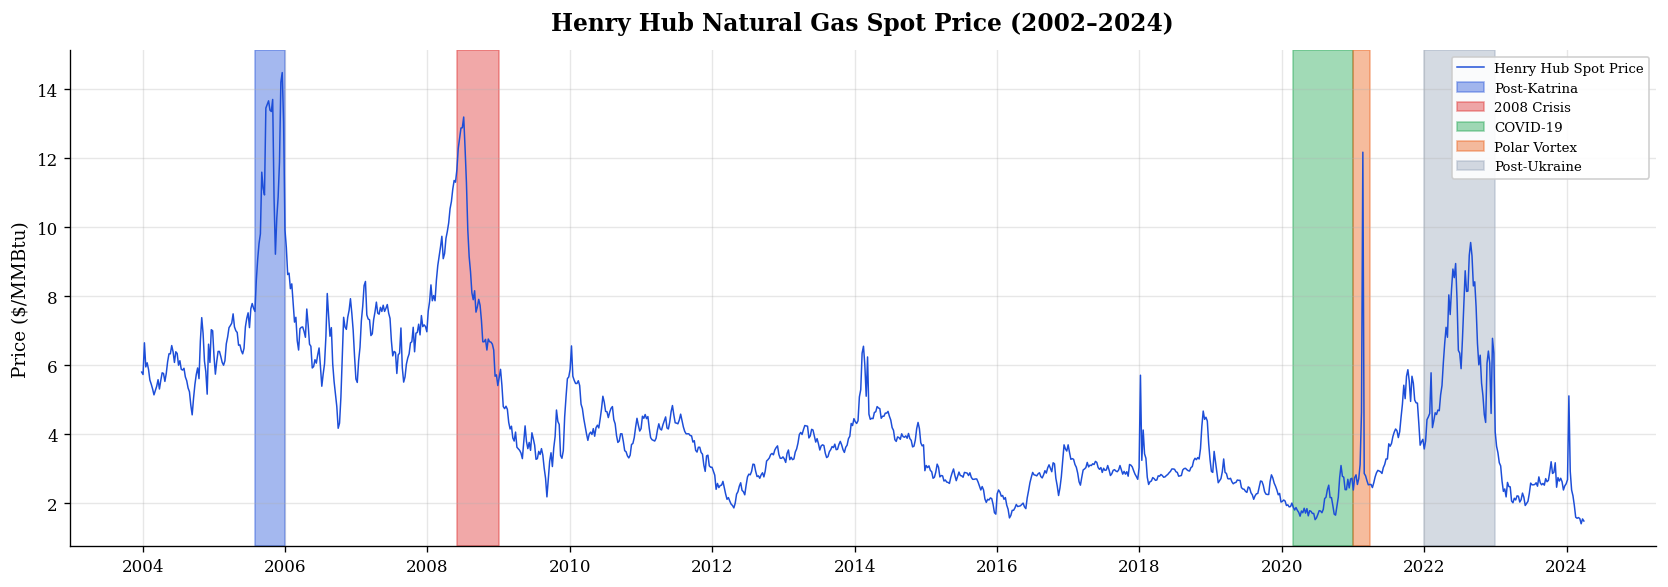

In [102]:
# plot 1 - HENRY HUB PRICE TIME SERIES
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['hh_price'], color='#1d4ed8', linewidth=0.9,
        label='Henry Hub Spot Price')

# shade key market regimes
regimes = [
    ('2005-08-01', '2005-12-31', '#1d4ed8', 'Post-Katrina'),
    ('2008-06-01', '2008-12-31', '#dc2626', '2008 Crisis'),
    ('2020-03-01', '2020-12-31', '#16a34a', 'COVID-19'),
    ('2021-01-01', '2021-03-31', '#ea580c', 'Polar Vortex'),
    ('2022-01-01', '2022-12-31', '#94a3b8', 'Post-Ukraine'),
]
for start, end, color, label in regimes:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               alpha=0.4, color=color, label=label)

ax.set_title('Henry Hub Natural Gas Spot Price (2002–2024)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Price ($/MMBtu)', fontsize=11)
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('plot1_price_timeseries.png', bbox_inches='tight')
plt.show()

To balance the right-sknewness exhibited by the raw data of the target variable (Henry Hub Weekly Spot Price), applying a log transform is necessary. 

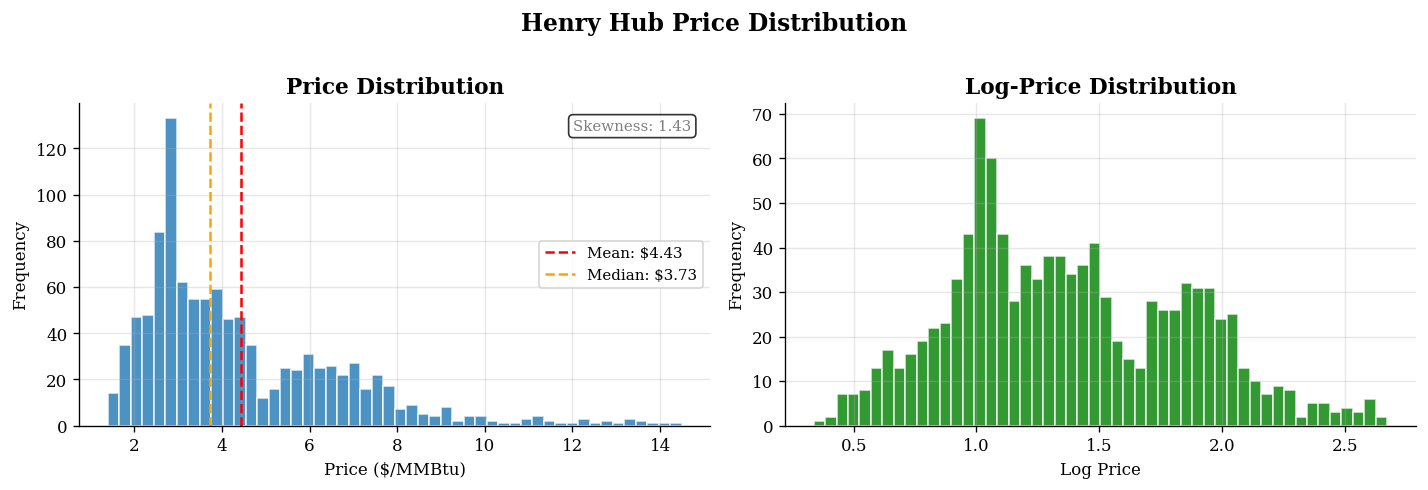

In [103]:
# plot 2 - Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram
axes[0].hist(df['hh_price'], bins=50, color='#1f77b4', alpha=0.8, edgecolor='white')
axes[0].axvline(df['hh_price'].mean(),   color='#FF0000',    linestyle='--',
                linewidth=1.5, label=f"Mean: ${df['hh_price'].mean():.2f}")
axes[0].axvline(df['hh_price'].median(), color='#FFA500', linestyle='--',
                linewidth=1.5, label=f"Median: ${df['hh_price'].median():.2f}")
axes[0].set_title('Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($/MMBtu)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# log-transformed distribution
axes[1].hist(np.log(df['hh_price']), bins=50, color='#008000', alpha=0.8, edgecolor='white')
axes[1].set_title('Log-Price Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Frequency')

# annotate skewness
skew = df['hh_price'].skew()
axes[0].text(0.97, 0.95, f'Skewness: {skew:.2f}',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=9, color='#808080',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Henry Hub Price Distribution', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot2_price_distribution.png', bbox_inches='tight')
plt.show()

Because the log-price distribution is considerably normalized, training on log-transformed prices is optimal.

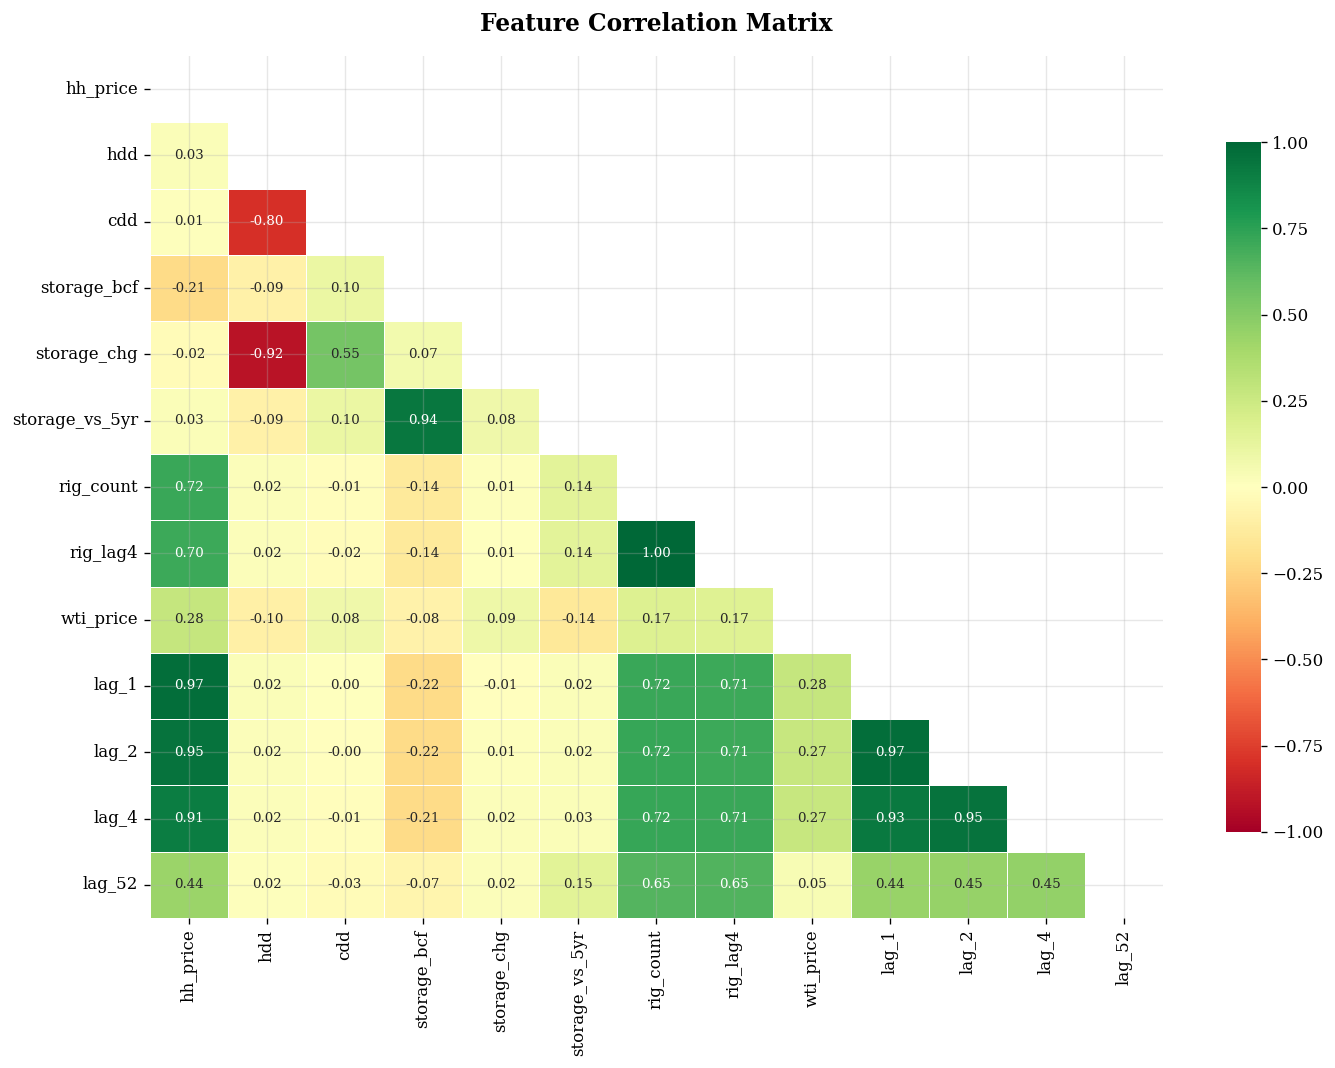

In [104]:
# plot 3 - Correlation Heatmap
corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Because natural gas price, n weeks in advance, displays autocorrelation, diluting its contribution to the models is necessary

From the variables set, the chosen features are below. 

To substantiate the chosen features from the correlation matrix, feature selection from LassoCV is cross validated with an RF Regressor. Noting the features that contributed to the residual is calculated as well. Lastly, the intersection & union of features are analyzed to note general correlation. Could be used in ensemble models...

In [105]:
# chosen features
FEATURES = [
    'hdd', 'cdd',
    'storage_bcf', 'storage_chg', 'storage_vs_5yr',
    'rig_count', 'rig_lag4',
    'wti_price',
    'lag_4', 'lag_52'
]

TARGET = 'hh_price'

X = df[FEATURES].copy()
y = df[TARGET].copy()

split_idx = int(len(df) * 0.80)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]   # fixed — was [:split_idx]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]   # fixed — was [:split_idx]

# partial out lag_4 autocorrelation before feature selection 
# lets supply-side features compete fairly without lag_4 dominating
lag_model = LinearRegression()
lag_model.fit(X_train[['lag_4']], y_train)
y_train_resid = y_train - lag_model.predict(X_train[['lag_4']])

print(f"y_train variance:       {y_train.var():.4f}")
print(f"y_train_resid variance: {y_train_resid.var():.4f}")
print(f"Variance explained by lag_4: "
      f"{(1 - y_train_resid.var()/y_train.var())*100:.1f}%")

# LASSO feature selection on residuals 
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train, y_train_resid)
selected_lasso = set(X_train.columns[lasso.coef_ != 0])

print(f"\nLASSO selected ({len(selected_lasso)}): {sorted(selected_lasso)}")

# RF feature importance on residuals 
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train_resid)
importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
selected_rf = set(importances[importances > importances.mean()].index)

print(f"RF selected   ({len(selected_rf)}): {sorted(selected_rf)}")

# intersection first, fallback to union if too sparse
intersection = selected_lasso & selected_rf
union        = selected_lasso | selected_rf

if len(intersection) >= 3:
    final_features = sorted(intersection)
    selection_method = "intersection"
elif len(union) >= 3:
    final_features = sorted(union)
    selection_method = "union"
else:
    # last resort — keep top 5 by RF importance
    final_features = importances.nlargest(5).index.tolist()
    selection_method = "RF top-5 (union too sparse)"

# including lag_4 regardless...
if 'lag_4' not in final_features:
    final_features = ['lag_4'] + final_features

print(f"\nSelection method: {selection_method}")
print(f"Final features ({len(final_features)}): {final_features}")

# fit a quick RF on final features to generate SHAP values
rf_shap = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_shap.fit(X_train[final_features], y_train_resid)

explainer    = shap.TreeExplainer(rf_shap)
shap_values  = explainer.shap_values(X_train[final_features])
mean_shap    = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=final_features
).sort_values(ascending=False)

print("\nSHAP importance on residuals (supply-side signal):")
print(mean_shap.round(4))

# top contributors for interaction candidates
top_features = mean_shap.head(4).index.tolist()
print(f"\nTop 4 for interaction engineering: {top_features}")

# pairwise interactions
interaction_cols = {}
for f1, f2 in combinations(top_features, 2):
    col_name = f"{f1}_x_{f2}"
    interaction_cols[col_name] = df[f1] * df[f2]

interaction_df = pd.DataFrame(interaction_cols, index=df.index)
df_enhanced    = pd.concat([df, interaction_df], axis=1)

# filter interactions by correlation with target
new_cols   = list(interaction_cols.keys())
corr_check = df_enhanced[new_cols + [TARGET]].corr()[TARGET].drop(TARGET)

print("\nInteraction correlations with hh_price:")
print(corr_check.sort_values(key=abs, ascending=False).round(4))

useful_interactions = corr_check[corr_check.abs() > 0.30].index.tolist()
print(f"\nInteractions cleared for inclusion: {useful_interactions}")

# final feature set?
FEATURES_FINAL = final_features + useful_interactions
print(f"\nFinal modeling feature set ({len(FEATURES_FINAL)} features):")
for f in FEATURES_FINAL:
    print(f"  {f}")

y_train variance:       5.3678
y_train_resid variance: 0.7300
Variance explained by lag_4: 86.4%

LASSO selected (7): ['hdd', 'rig_count', 'rig_lag4', 'storage_bcf', 'storage_chg', 'storage_vs_5yr', 'wti_price']
RF selected   (2): ['lag_4', 'storage_vs_5yr']

Selection method: union
Final features (8): ['hdd', 'lag_4', 'rig_count', 'rig_lag4', 'storage_bcf', 'storage_chg', 'storage_vs_5yr', 'wti_price']

SHAP importance on residuals (supply-side signal):
lag_4             0.2456
rig_count         0.1522
wti_price         0.0874
rig_lag4          0.0870
hdd               0.0625
storage_vs_5yr    0.0576
storage_chg       0.0507
storage_bcf       0.0373
dtype: float64

Top 4 for interaction engineering: ['lag_4', 'rig_count', 'wti_price', 'rig_lag4']

Interaction correlations with hh_price:
lag_4_x_rig_count        0.8362
lag_4_x_rig_lag4         0.8326
lag_4_x_wti_price        0.7936
rig_count_x_rig_lag4     0.7349
rig_count_x_wti_price    0.6853
wti_price_x_rig_lag4     0.6766
Name: hh_

Since this is a temporal-based study, enhancing the model could involve providing it feature derivates...

E.G. - Knowing how fast the storage level is changing may be more useful than just knowing the storage level on a weekly basis...

Since there are multiple historical events causing spot price spikes, viewed as volatile anomalies by the ensemble models, capturing the price fluctuations around the mean over time periods may provide the model a clearer signal on when to adapt predictively. 

Having the week-over-week net storage change (storage_chg) and the storage deviation from 5-year average (storage_vs_5yr), both, only provide the displacement of weekly natural gas levels and that difference from the 5-year average limits the models' ability to understand how these changes are occuring. Therefore, having the ensemble models aware of how quickly these levels and difference are changing, respectively, could assist for adjusting predictions. This strategy will also be applied to storage level (storage_bcf), rig count (rig_count), crude oil spot price (wti_price), and the target variable, Henry Hub spot price (hh_price). These rates will be measured over 4- and 8-week time intervals. 

In [106]:
# indexing the date column 
if 'date' in df_enhanced.columns:
    df_enhanced = df_enhanced.set_index('date')
df_enhanced = df_enhanced.sort_index()
df_enhanced.index = pd.to_datetime(df_enhanced.index)

# applying the log transform (observed earler...)
df_enhanced['hh_price_log'] = np.log(df_enhanced['hh_price'])
df = df_enhanced.copy()

# rolling stats 
# std for volatility and z-score for deviation from mean 
df['price_vol_8w']   = df['hh_price'].rolling(8).std()
df['storage_zscore'] = (
    (df['storage_vs_5yr'] - df['storage_vs_5yr'].rolling(52).mean()) /
     df['storage_vs_5yr'].rolling(52).std()
)

# momemtum and velocity derivatives
# 'how quickly are these features shifting quantitatively?...'
df['storage_roc_4w'] = (df['storage_bcf'] - df['storage_bcf'].shift(4)) / df['storage_bcf'].shift(4)
df['storage_roc_8w'] = (df['storage_bcf'] - df['storage_bcf'].shift(8)) / df['storage_bcf'].shift(8)
df['rig_roc_4w']     = (df['rig_count']   - df['rig_count'].shift(4))   / df['rig_count'].shift(4)
df['rig_roc_8w']     = (df['rig_count']   - df['rig_count'].shift(8))   / df['rig_count'].shift(8)
df['wti_roc_4w']     = (df['wti_price']   - df['wti_price'].shift(4))   / df['wti_price'].shift(4)
df['wti_roc_8w']     = (df['wti_price']   - df['wti_price'].shift(8))   / df['wti_price'].shift(8)
df['price_roc_4w']   = (df['hh_price']    - df['hh_price'].shift(4))    / df['hh_price'].shift(4)
df['price_roc_8w']   = (df['hh_price']    - df['hh_price'].shift(8))    / df['hh_price'].shift(8)
df['storage_accel']  = df['storage_roc_4w'] - df['storage_roc_8w']
df['price_accel']    = df['price_roc_4w']   - df['price_roc_8w']

# replace inf/-inf with NaN then forward-fill
roc_cols = [
    'storage_roc_4w', 'storage_roc_8w',
    'rig_roc_4w',     'rig_roc_8w',
    'wti_roc_4w',     'wti_roc_8w',
    'price_roc_4w',   'price_roc_8w',
    'storage_accel',  'price_accel'
]
df[roc_cols] = df[roc_cols].replace([np.inf, -np.inf], np.nan)
df[roc_cols] = df[roc_cols].ffill()

# clip extreme outliers — ROC values beyond ±5 (500%) are likely data artifacts
df[roc_cols] = df[roc_cols].clip(-5, 5)

# rolling window stats 
for w in [4, 8, 26]:
    df[f'price_mean_{w}w']   = df['hh_price'].rolling(w).mean()
    df[f'price_std_{w}w']    = df['hh_price'].rolling(w).std()
    df[f'price_min_{w}w']    = df['hh_price'].rolling(w).min()
    df[f'price_max_{w}w']    = df['hh_price'].rolling(w).max()
    df[f'storage_mean_{w}w'] = df['storage_bcf'].rolling(w).mean()
    df[f'storage_std_{w}w']  = df['storage_bcf'].rolling(w).std()

for w in [4, 8]:
    df[f'hdd_mean_{w}w'] = df['hdd'].rolling(w).mean()
    df[f'cdd_mean_{w}w'] = df['cdd'].rolling(w).mean()

df = df.dropna()
df.index = pd.to_datetime(df.index)

# diagnostics
print(df.index.dtype)
print(df.index[:3])
print(f"Rows before 2019:  {(df.index < '2019-01-01').sum()}")
print(f"Rows 2015–2019:    {((df.index >= '2015-01-01') & (df.index < '2019-01-01')).sum()}")
print(f"Rows 2019 onward:  {(df.index >= '2019-01-01').sum()}")

datetime64[ns]
DatetimeIndex(['2004-12-18', '2004-12-25', '2005-01-01'], dtype='datetime64[ns]', name='date', freq=None)
Rows before 2019:  731
Rows 2015–2019:    209
Rows 2019 onward:  274


To properly judge the performance of the ensemble models (XGBoost and RFRegressor), a baseline model (RidgeCV) will only host the highest correlative features to the target (excluding the lag prices). 

For the training split: 
Because there are stable and volatile periods from 2002 to 2019 (including Post-Katrina and 2008 financial crisis), this window is chosen to train the model to be sensitive to both spot price behaviors. 

For the test split:
The stable window (where spot prices, relatively, do not fluctuate as much...) is defined from January 2015 - January 2019. 
The volatile window (where spot prices, relatively, fluctuate sporadically...) is defined from January 2019 onward. 

Out of all ensemble models, XGBoost, unequivocally, is most sensitive to non-linear fluctuations within time-series data. Therefore, the parameters for the XGBoost are selected via Bayesian tuning, once the model runs at least once. This ensures the model is optimized for the data provided. Could eventually build the same recursive process for the other models at some point...

For evaluation metrics: 
These models are parsing through a high quantity of data points, making predictions within windows hosting stochastic data. Therefore, having metrics measuring error provides necessary feedback. 
Mean absolute error (MAE) captures the average magnitude of error (difference between the actual Henry Hub Spot Price and the observed Henry Hub Spot Price). Since there are unforeseen dataspikes within this dataset, the models may have a low likelihood of accurately predicting the spikes (> $9/MMBtu), given there aren't many. Therefore, receiving a clearer signal on how the model handles these spikes helps with interpretation. So, root mean squared error (RMSE) will be used. Receiving a clear picture on the loss of the model (normal mean squared error - NMSE), irrespective of the scale variance, notes how closely the predicted Henry Hub Spot Price is to the variance of the actual Henry Hub spot price. Thiel's Inequality Coefficient (TIC) is also used to note the absolute difference in predicted Henry Hub Spot Price. In conjuction with R-squared, a sound conclusion can be infered regarding the performance of the model. 

Because there is overlap between the full training data and stable window, a walkforward CV is implemented to prevent data leakage. This ensures the model never views the test data preemptively. 

Curious to know if a stacked regressive model could handle the diversity within the data better than just the ensemble models independently. Therefore, a stacked model including an RFRegressor, CatBoostCV, LightGBM and XGBoost will act as a comparative tool for the independent ensemble models. This model will specialize in capturing categorical relationships via CatBoostCV, recognize sharp data shifts via LightGBM and smooth out noise via XGBoost.  

In [107]:
# feature sets - for both the baseline and ensemble models
FEATURES_BASELINE = ['storage_bcf', 'storage_vs_5yr', 'rig_count', 'wti_price']

FEATURES_ENSEMBLE_V2 = [
    # core lag and supply
    'lag_4', 'storage_bcf', 'storage_chg', 'storage_vs_5yr',
    # rolling volatility and z-score
    'price_vol_8w', 'storage_zscore',
    # price rolling windows
    'price_mean_4w',  'price_std_4w',  'price_min_4w',  'price_max_4w',
    'price_mean_8w',  'price_std_8w',  'price_min_8w',  'price_max_8w',
    'price_mean_26w', 'price_std_26w', 'price_min_26w', 'price_max_26w',
    # storage rolling windows
    'storage_mean_4w',  'storage_std_4w',
    'storage_mean_8w',  'storage_std_8w',
    'storage_mean_26w', 'storage_std_26w',
    # weather rolling windows
    'hdd_mean_4w', 'hdd_mean_8w',
    'cdd_mean_4w', 'cdd_mean_8w',
    # momentum derivatives
    'storage_roc_4w', 'storage_roc_8w',
    'rig_roc_4w',     'rig_roc_8w',
    'wti_roc_4w',     'wti_roc_8w',
    'price_roc_4w',   'price_roc_8w',
    # acceleration
    'storage_accel', 'price_accel',
]

print(f"\nTotal V2 features: {len(FEATURES_ENSEMBLE_V2)}")
print(f"NaN check: {df[FEATURES_ENSEMBLE_V2].isna().sum().sum()} NaNs")

# make_windows 
def make_windows(df, features, target_log='hh_price_log'):
    X = df[features].copy()
    y = df[target_log].copy()

    full_train_mask    =  df.index < '2019-01-01'
    stable_eval_mask   = (df.index >= '2015-01-01') & (df.index < '2019-01-01')
    volatile_eval_mask =  df.index >= '2019-01-01'

    X_train    = X[full_train_mask];    y_train    = y[full_train_mask]
    X_stable   = X[stable_eval_mask];   y_stable   = y[stable_eval_mask]
    X_volatile = X[volatile_eval_mask]; y_volatile = y[volatile_eval_mask]

    scaler = RobustScaler()
    X_train_sc    = pd.DataFrame(scaler.fit_transform(X_train),
                                 columns=features, index=X_train.index)
    X_stable_sc   = pd.DataFrame(scaler.transform(X_stable),
                                 columns=features, index=X_stable.index)
    X_volatile_sc = pd.DataFrame(scaler.transform(X_volatile),
                                 columns=features, index=X_volatile.index)

    return {
        'X_train_sc':    X_train_sc,
        'X_stable_sc':   X_stable_sc,
        'X_volatile_sc': X_volatile_sc,
        'y_train':       y_train,
        'y_stable':      y_stable,
        'y_volatile':    y_volatile,
    }

# build windows 
baseline_data    = make_windows(df, FEATURES_BASELINE)
ensemble_data_v2 = make_windows(df, FEATURES_ENSEMBLE_V2)

print(f"\nBaseline train:    {len(baseline_data['X_train_sc'])} samples")
print(f"Ensemble V2 train: {len(ensemble_data_v2['X_train_sc'])} samples")

# raw targets
y_stable_raw   = df['hh_price'][
    (df.index >= '2015-01-01') & (df.index < '2019-01-01')]
y_volatile_raw = df['hh_price'][df.index >= '2019-01-01']

# load saved params
with open('stacking_params.json', 'r', encoding='utf-8') as file:
    saved_params = json.load(file)

xgb_params_stable_tuned   = {**saved_params['xgb_stable'],
                              'random_state': 42, 'verbosity': 0}
xgb_params_volatile_tuned = {**saved_params['xgb_volatile'],
                              'random_state': 42, 'verbosity': 0}

print(f"\nLoaded stable   XGBoost params: {xgb_params_stable_tuned}")
print(f"Loaded volatile XGBoost params: {xgb_params_volatile_tuned}")

tscv = TimeSeriesSplit(n_splits=3, gap=4)

# static model params
baseline_models = {
    'Ridge': RidgeCV(
        alphas=[0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000],
        cv=tscv,
        scoring='neg_mean_squared_error'
    )
}

rf_params = {
    'n_estimators':      691,
    'max_depth':         10,
    'min_samples_split': 20,
    'max_features':      0.8988595306115781
}

lgbm_params = {
    'n_estimators':      500,
    'learning_rate':     0.05,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'random_state':      42,
    'verbose':           -1
}

catboost_params = {
    'iterations':    500,
    'learning_rate': 0.05,
    'depth':         4,
    'l2_leaf_reg':   3,
    'random_seed':   42,
    'verbose':       0
}

# metrics
def evaluate(y_true_log, y_pred_log):
    y_true = np.exp(np.array(y_true_log))
    y_pred = np.exp(np.array(y_pred_log))
    mae      = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    r2       = r2_score(y_true, y_pred)
    nmse     = np.mean((y_true - y_pred)**2 / (y_true * y_pred))
    tic      = (np.sqrt(np.mean((y_true - y_pred)**2)) /
                (np.sqrt(np.mean(y_true**2)) + np.sqrt(np.mean(y_pred**2))))
    return {
        'MAE':  round(mae,      4),
        'RMSE': round(rmse_val, 4),
        'R2':   round(r2,       4),
        'NMSE': round(nmse,     4),
        'TIC':  round(tic,      4)
    }

def print_metrics(label, metrics):
    print(f"  {label}: MAE={metrics['MAE']}  RMSE={metrics['RMSE']}  "
          f"R²={metrics['R2']}  NMSE={metrics['NMSE']}  TIC={metrics['TIC']}")

# CV function
def run_cv(models_dict, data, label):
    print(f"\n{'=' * 55}")
    print(f"WALK-FORWARD CV — {label}")
    print(f"{'=' * 55}")
    X_tr_sc = data['X_train_sc']
    y_tr    = data['y_train']
    results = {name: [] for name in models_dict}
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_tr_sc)):
        for name, model in models_dict.items():
            model.fit(X_tr_sc.iloc[tr_idx], y_tr.iloc[tr_idx])
            preds = model.predict(X_tr_sc.iloc[te_idx])
            results[name].append(evaluate(y_tr.iloc[te_idx].values, preds))
    print(f"\n{'Model':<16} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'NMSE':>8} {'TIC':>8}")
    print("-" * 56)
    for name, folds in results.items():
        avg = {k: round(np.mean([f[k] for f in folds]), 4)
               for k in ['MAE', 'RMSE', 'R2', 'NMSE', 'TIC']}
        print(f"{name:<16} {avg['MAE']:>8} {avg['RMSE']:>8} "
              f"{avg['R2']:>8} {avg['NMSE']:>8} {avg['TIC']:>8}")
    return results

# window eval function
def run_window_eval(models_dict, data, label):
    print(f"\n{'=' * 55}")
    print(f"WINDOW EVALUATION — {label}")
    print(f"{'=' * 55}")
    window_results = {}
    for name, model in models_dict.items():
        print(f"\n  Model: {name}")
        model.fit(data['X_train_sc'], data['y_train'])
        if name == 'Ridge':
            print(f"  Best alpha: {model.alpha_}")
        pred_stable   = model.predict(data['X_stable_sc'])
        pred_volatile = model.predict(data['X_volatile_sc'])
        m_stable   = evaluate(data['y_stable'].values,   pred_stable)
        m_volatile = evaluate(data['y_volatile'].values, pred_volatile)
        print_metrics("Stable   2015–2019", m_stable)
        print_metrics("Volatile 2019–2024", m_volatile)
        window_results[name] = {
            'stable':            m_stable,
            'volatile':          m_volatile,
            'pred_stable_log':   pred_stable,
            'pred_volatile_log': pred_volatile
        }
    return window_results

# enhanced stacking — 4 base learners + RidgeCV meta
def run_enhanced_stacking(data, label):
    print(f"\n{'=' * 60}")
    print(f"ENHANCED STACKING — {label}")
    print(f"{'=' * 60}")

    X_train = data['X_train_sc']
    y_train = data['y_train']

    base_learners = {
        'rf':       RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1),
        'xgb':      XGBRegressor(**xgb_params_volatile_tuned),
        'lgbm':     LGBMRegressor(**lgbm_params),        
        'catboost': CatBoostRegressor(**catboost_params)
    }

    n        = len(X_train)
    oof      = {name: np.zeros(n) for name in base_learners}
    filled   = np.zeros(n, dtype=bool)

    print("\n  Generating OOF predictions...")
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr  = X_train.iloc[tr_idx];  y_tr  = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        for name, model in base_learners.items():
            model.fit(X_tr, y_tr)
            oof[name][val_idx] = model.predict(X_val)
        filled[val_idx] = True
        print(f"    Fold {fold+1} complete — {filled.sum()} OOF samples filled")

    # RidgeCV meta-learner
    meta_X = np.column_stack([oof[name][filled] for name in base_learners])
    meta_y = y_train.values[filled]

    meta = RidgeCV(
        alphas=[0.01, 0.1, 1, 10, 100, 500],
        cv=TimeSeriesSplit(n_splits=3)
    )
    meta.fit(meta_X, meta_y)

    print(f"\n  Meta-learner RidgeCV — best alpha: {meta.alpha_}")
    print(f"  Base learner weights:")
    for name, coef in zip(base_learners.keys(), meta.coef_):
        print(f"    {name:<12}: {coef:.4f}")

    # refit on full training data
    print("\n  Refitting base learners on full training window...")
    for name, model in base_learners.items():
        model.fit(X_train, y_train)
        print(f"    {name} done")

    def stack_predict(X_eval):
        preds = np.column_stack([
            model.predict(X_eval) for model in base_learners.values()
        ])
        return meta.predict(preds)

    pred_stable   = stack_predict(data['X_stable_sc'])
    pred_volatile = stack_predict(data['X_volatile_sc'])

    m_stable   = evaluate(data['y_stable'].values,   pred_stable)
    m_volatile = evaluate(data['y_volatile'].values, pred_volatile)

    print_metrics("\n  Stable   2015–2019", m_stable)
    print_metrics("  Volatile 2019–2024", m_volatile)

    return {
        'base_learners':     base_learners,
        'meta':              meta,
        'stable':            m_stable,
        'volatile':          m_volatile,
        'pred_stable_log':   pred_stable,
        'pred_volatile_log': pred_volatile
    }


Total V2 features: 38
NaN check: 0 NaNs

Baseline train:    731 samples
Ensemble V2 train: 731 samples

Loaded stable   XGBoost params: {'n_estimators': 867, 'max_depth': 6, 'learning_rate': 0.00833901482065674, 'subsample': 0.8166293261772732, 'colsample_bytree': 0.6181520166421762, 'min_child_weight': 4, 'reg_alpha': 0.01001558569169642, 'reg_lambda': 0.17678150387985955, 'gamma': 0.011784000797286044, 'random_state': 42, 'verbosity': 0}
Loaded volatile XGBoost params: {'n_estimators': 1020, 'max_depth': 2, 'learning_rate': 0.0644473883841545, 'subsample': 0.5719939506249336, 'colsample_bytree': 0.7720078467616509, 'min_child_weight': 6, 'reg_alpha': 0.02743877595006156, 'reg_lambda': 0.4356152007515041, 'gamma': 0.011329240452876721, 'random_state': 42, 'verbosity': 0}


In [108]:
# running models - baseline, ensemble, and stack
baseline_cv      = run_cv(baseline_models, baseline_data,
                          "BASELINE — Ridge, no lags")
baseline_windows = run_window_eval(baseline_models, baseline_data,
                                   "BASELINE — Ridge, no lags")

rf_models  = {'RandomForest': RandomForestRegressor(
                  **rf_params, random_state=42, n_jobs=-1)}
rf_windows = run_window_eval(rf_models, ensemble_data_v2,
                              "RandomForest — V2 features")

xgb_models  = {'XGBoost': XGBRegressor(**xgb_params_volatile_tuned)}
xgb_windows = run_window_eval(xgb_models, ensemble_data_v2,
                               "XGBoost — volatile-tuned, V2 features")

enhanced_results = run_enhanced_stacking(
    ensemble_data_v2,
    "RF + XGB + LGBM + CatBoost → RidgeCV"
)

# summary table
print(f"\n{'=' * 75}")
print("Final Performance Summary")
print(f"{'=' * 75}")
print(f"{'Model':<38} {'Stable R²':>10} {'Volatile R²':>12}")
print("-" * 62)
print(f"{'Ridge (baseline, no lags)':<38}"
      f"{baseline_windows['Ridge']['stable']['R2']:>10}"
      f"{baseline_windows['Ridge']['volatile']['R2']:>12}")
print(f"{'RandomForest (V2 features)':<38}"
      f"{rf_windows['RandomForest']['stable']['R2']:>10}"
      f"{rf_windows['RandomForest']['volatile']['R2']:>12}")
print(f"{'XGBoost (volatile-tuned, V2)':<38}"
      f"{xgb_windows['XGBoost']['stable']['R2']:>10}"
      f"{xgb_windows['XGBoost']['volatile']['R2']:>12}")
print(f"{'Enhanced Stack (4→RidgeCV, V2)':<38}"
      f"{enhanced_results['stable']['R2']:>10}"
      f"{enhanced_results['volatile']['R2']:>12}")


WALK-FORWARD CV — BASELINE — Ridge, no lags

Model                 MAE     RMSE       R²     NMSE      TIC
--------------------------------------------------------
Ridge              1.4394   1.6205  -1.4212   0.1667   0.1706

WINDOW EVALUATION — BASELINE — Ridge, no lags

  Model: Ridge
  Best alpha: 10.0
  Stable   2015–2019: MAE=0.3985  RMSE=0.5339  R²=-0.0072  NMSE=0.0346  TIC=0.0937
  Volatile 2019–2024: MAE=1.1984  RMSE=1.8653  R²=0.0252  NMSE=0.1919  TIC=0.274

WINDOW EVALUATION — RandomForest — V2 features

  Model: RandomForest
  Stable   2015–2019: MAE=0.0703  RMSE=0.1285  R²=0.9417  NMSE=0.0016  TIC=0.0223
  Volatile 2019–2024: MAE=0.2956  RMSE=0.6345  R²=0.8872  NMSE=0.0202  TIC=0.0803

WINDOW EVALUATION — XGBoost — volatile-tuned, V2 features

  Model: XGBoost
  Stable   2015–2019: MAE=0.0655  RMSE=0.11  R²=0.9573  NMSE=0.0009  TIC=0.0191
  Volatile 2019–2024: MAE=0.2163  RMSE=0.4751  R²=0.9368  NMSE=0.0114  TIC=0.0606

ENHANCED STACKING — RF + XGB + LGBM + CatBoost → Rid

The baseline model performed poorly. This result was not unforeseen, as training an architecturally linear model on no lag prices yet expecting it to accurately predict non-linear spot price trends is a far fetched request. 

Although the RFRegressor and stacked models performed well, unequivocally, XGBoost outperformed every moddel, including the hybrid model presented by the comparative study. 

Bayesian tuning

In [109]:
# capture data locally - matching current make_windows key names
X_STABLE_TRAIN = ensemble_data_v2['X_train_sc'].copy()
Y_STABLE_TRAIN = ensemble_data_v2['y_train'].copy()
X_STABLE_EVAL  = ensemble_data_v2['X_stable_sc'].copy()
Y_STABLE_EVAL  = ensemble_data_v2['y_stable'].copy()

X_VOL_TRAIN = ensemble_data_v2['X_train_sc'].copy()
Y_VOL_TRAIN = ensemble_data_v2['y_train'].copy()
X_VOL_EVAL  = ensemble_data_v2['X_volatile_sc'].copy()
Y_VOL_EVAL  = ensemble_data_v2['y_volatile'].copy()

# sample weights for volatile — upweight recent observations
train_dates   = X_VOL_TRAIN.index
days_from_end = (train_dates.max() - train_dates).days.to_numpy()
sw = np.exp(-0.3 * days_from_end / days_from_end.max())
sw = sw / sw.sum() * len(sw)

print(f"Stable train:   {len(X_STABLE_TRAIN)} samples "
      f"({X_STABLE_TRAIN.index[0].date()} → {X_STABLE_TRAIN.index[-1].date()})")
print(f"Stable eval:    {len(X_STABLE_EVAL)} samples "
      f"({X_STABLE_EVAL.index[0].date()} → {X_STABLE_EVAL.index[-1].date()})")
print(f"Volatile train: {len(X_VOL_TRAIN)} samples "
      f"({X_VOL_TRAIN.index[0].date()} → {X_VOL_TRAIN.index[-1].date()})")
print(f"Volatile eval:  {len(X_VOL_EVAL)} samples "
      f"({X_VOL_EVAL.index[0].date()} → {X_VOL_EVAL.index[-1].date()})")

# stable Optuna objective
def stable_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.10, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.90),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.85),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 25),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.01, 3.0, log=True),
        'random_state': 42, 'verbosity': 0
    }
    m = XGBRegressor(**params)
    m.fit(X_STABLE_TRAIN, Y_STABLE_TRAIN)
    r2 = r2_score(Y_STABLE_EVAL, m.predict(X_STABLE_EVAL))
    trial.set_user_attr('r2_stable', round(r2, 4))
    return r2

# volatile Optuna objective
def volatile_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.10, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.90),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.85),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 25),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.01, 3.0, log=True),
        'random_state': 42, 'verbosity': 0
    }
    m = XGBRegressor(**params)
    m.fit(X_VOL_TRAIN, Y_VOL_TRAIN, sample_weight=sw)
    r2 = r2_score(Y_VOL_EVAL, m.predict(X_VOL_EVAL))
    trial.set_user_attr('r2_volatile', round(r2, 4))
    return r2

# run both studies
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_stable = optuna.create_study(direction='maximize')
study_stable.optimize(stable_objective, n_trials=400, show_progress_bar=True)

study_vol = optuna.create_study(direction='maximize')
study_vol.optimize(volatile_objective, n_trials=400, show_progress_bar=True)

# report
print(f"\nStable-targeted XGBoost:")
print(f"  Stable R²:   {study_stable.best_trial.user_attrs['r2_stable']}")
print(f"  Params: {study_stable.best_params}")

print(f"\nVolatile-targeted XGBoost:")
print(f"  Volatile R²: {study_vol.best_trial.user_attrs['r2_volatile']}")
print(f"  Params: {study_vol.best_params}")

# update params for stacking
xgb_params_stable_tuned = {**study_stable.best_params,
                            'random_state': 42, 'verbosity': 0}
xgb_params_volatile_tuned = {**study_vol.best_params,
                              'random_state': 42, 'verbosity': 0}

with open('stacking_params.json', 'w') as f:
    json.dump({
        'xgb_stable':   study_stable.best_params,
        'xgb_volatile': study_vol.best_params
    }, f, indent=2)
print("\nSaved to stacking_params.json")

Stable train:   731 samples (2004-12-18 → 2018-12-29)
Stable eval:    209 samples (2015-01-03 → 2018-12-29)
Volatile train: 731 samples (2004-12-18 → 2018-12-29)
Volatile eval:  274 samples (2019-01-05 → 2024-03-30)


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]


Stable-targeted XGBoost:
  Stable R²:   0.9869
  Params: {'n_estimators': 1173, 'max_depth': 5, 'learning_rate': 0.029929449920426145, 'subsample': 0.8678776487376034, 'colsample_bytree': 0.5497038352613401, 'min_child_weight': 3, 'reg_alpha': 0.010029655790774791, 'reg_lambda': 0.07484524756008978, 'gamma': 0.01000863328248906}

Volatile-targeted XGBoost:
  Volatile R²: 0.9531
  Params: {'n_estimators': 768, 'max_depth': 2, 'learning_rate': 0.04141180110331944, 'subsample': 0.507830902259591, 'colsample_bytree': 0.776512389442607, 'min_child_weight': 5, 'reg_alpha': 0.010405214331699695, 'reg_lambda': 0.17499212685476292, 'gamma': 0.011109964475496968}

Saved to stacking_params.json


SHAP analysis

Verify if the XGBoost model is primarily learning price momentum or supply-side fundamentals. 

Clarity on contributing variables to output on both rolling-windows and non-rolling-windows model. 

SHAP Feature Importance — Stable vs. Volatile Window
Feature                    Stable SHAP  S.Rank   Vol SHAP  V.Rank  Shift
---------------------------------------------------------------------------
price_mean_4w                   0.2152       1     0.2363       1      0
price_max_4w                    0.1057       2     0.1285       2      0
price_min_4w                    0.0610       3     0.0679       3      0
price_roc_4w                    0.0307       4     0.0476       4      0
price_max_8w                    0.0122       5     0.0223       5      0
price_min_8w                    0.0081       7     0.0111       6     +1
price_mean_8w                   0.0082       6     0.0081       7     -1
price_roc_8w                    0.0047       8     0.0066       8      0
lag_4                           0.0035      10     0.0049       9     +1
price_mean_26w                  0.0045       9     0.0038      10     -1
price_std_4w                    0.0014      14     0.0028      11   

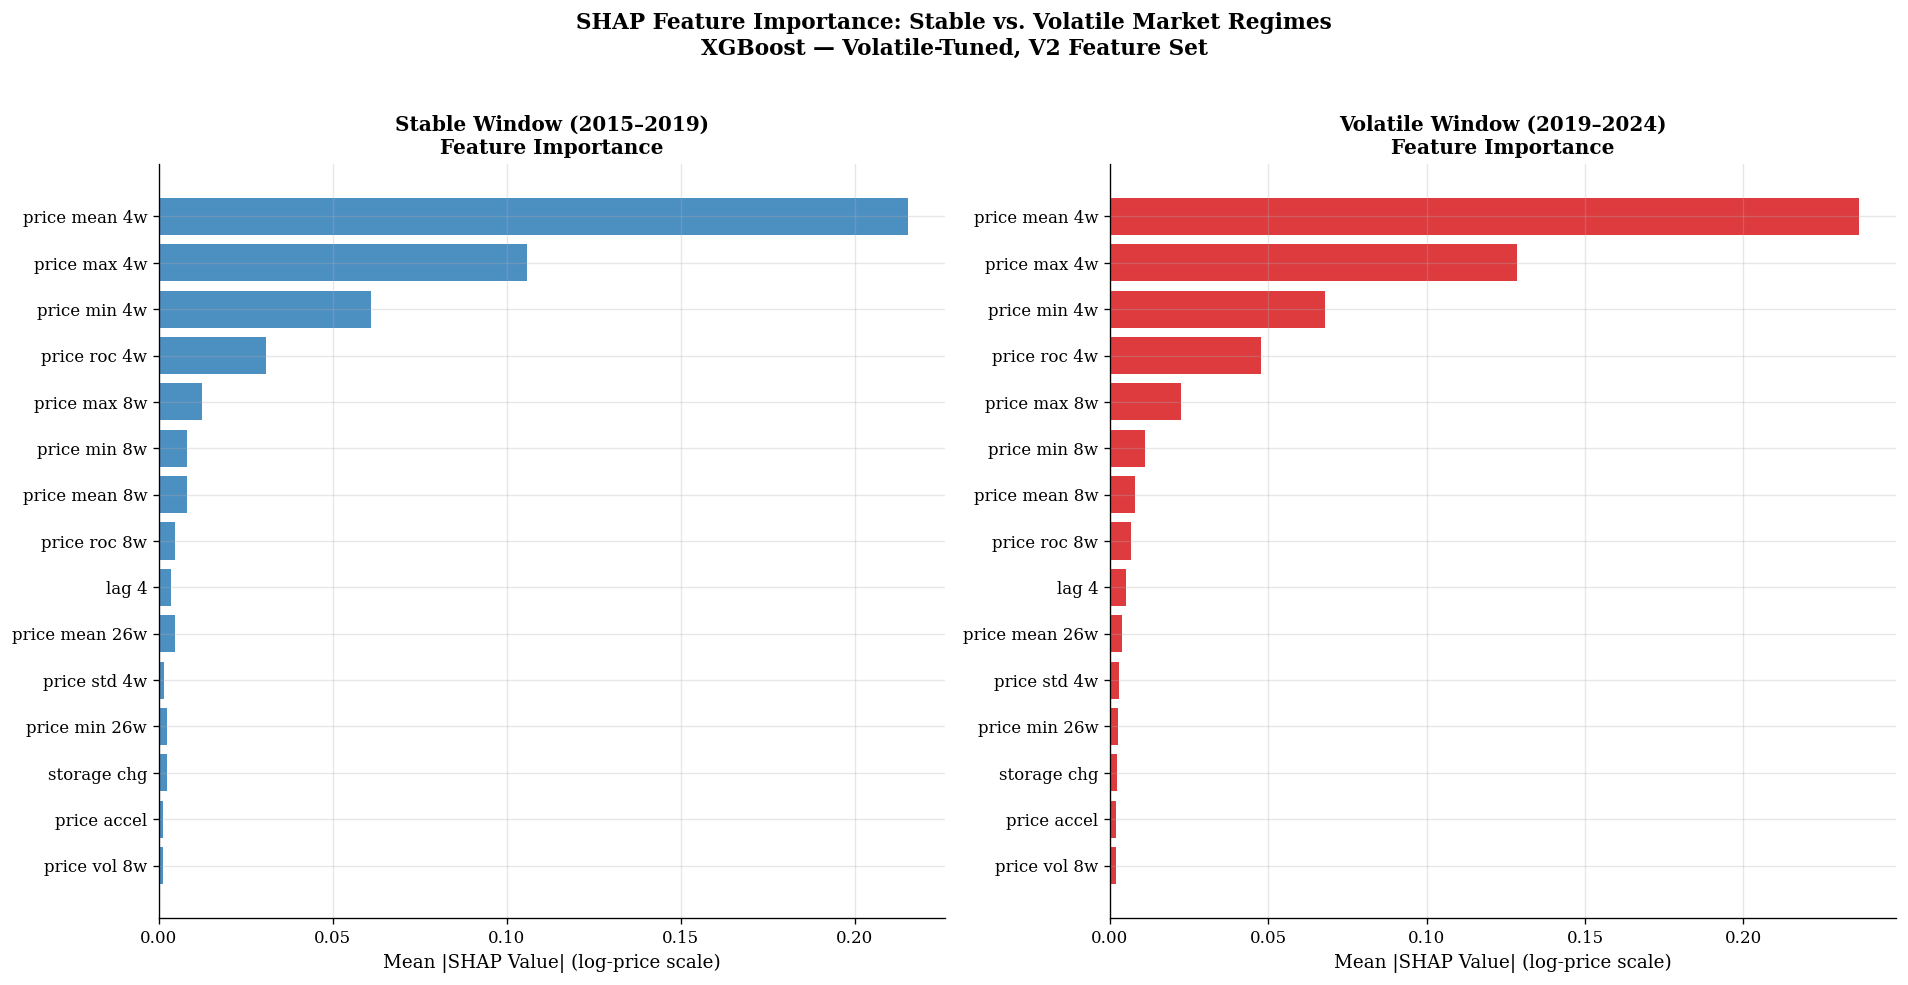


Features with largest rank shift across regimes
(positive = more important in volatile window)

Rose in importance during volatile window:
                Stable_Rank  Volatile_Rank  Rank_Shift
hdd_mean_8w              32             24           8
price_std_26w            30             25           5
price_max_26w            19             16           3
price_std_4w             14             11           3
storage_roc_4w           22             19           3

Fell in importance during volatile window:
                 Stable_Rank  Volatile_Rank  Rank_Shift
storage_std_8w            13             17          -4
storage_mean_8w           17             21          -4
hdd_mean_4w               26             30          -4
storage_vs_5yr            27             31          -4
storage_std_26w           24             29          -5


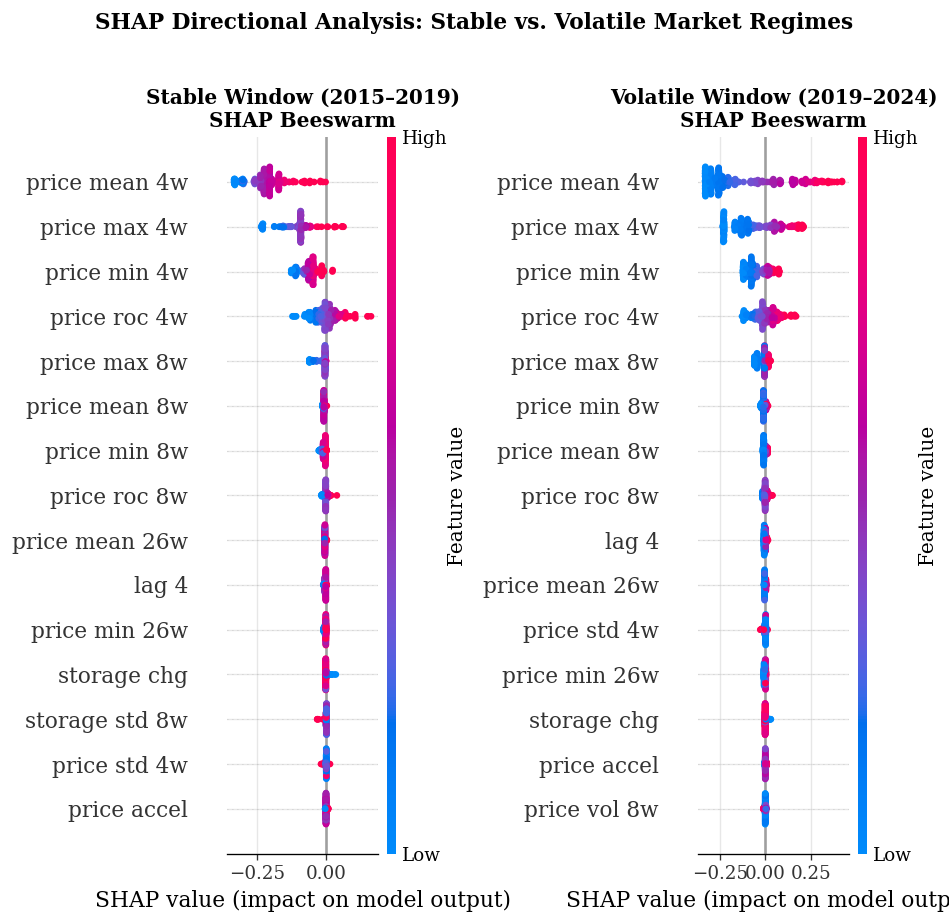


Saved: shap_regime_comparison.png
Saved: shap_beeswarm_comparison.png


In [110]:
# fit final XGBoost on full training data 
final_xgb = XGBRegressor(**xgb_params_volatile_tuned)
final_xgb.fit(ensemble_data_v2['X_train_sc'], ensemble_data_v2['y_train'])

# SHAP explainer
explainer = shap.TreeExplainer(final_xgb)

shap_stable   = explainer.shap_values(ensemble_data_v2['X_stable_sc'])
shap_volatile = explainer.shap_values(ensemble_data_v2['X_volatile_sc'])

# mean absolute SHAP per feature per window
mean_shap_stable   = pd.Series(
    np.abs(shap_stable).mean(axis=0),
    index=FEATURES_ENSEMBLE_V2
).sort_values(ascending=False)

mean_shap_volatile = pd.Series(
    np.abs(shap_volatile).mean(axis=0),
    index=FEATURES_ENSEMBLE_V2
).sort_values(ascending=False)

# comparison table
shap_df = pd.DataFrame({
    'Stable_SHAP':   mean_shap_stable,
    'Volatile_SHAP': mean_shap_volatile
})
shap_df['Stable_Rank']   = shap_df['Stable_SHAP'].rank(ascending=False).astype(int)
shap_df['Volatile_Rank'] = shap_df['Volatile_SHAP'].rank(ascending=False).astype(int)
shap_df['Rank_Shift']    = shap_df['Stable_Rank'] - shap_df['Volatile_Rank']

shap_df = shap_df.sort_values('Volatile_SHAP', ascending=False)

print("=" * 75)
print("SHAP Feature Importance — Stable vs. Volatile Window")
print("=" * 75)
print(f"{'Feature':<25} {'Stable SHAP':>12} {'S.Rank':>7} "
      f"{'Vol SHAP':>10} {'V.Rank':>7} {'Shift':>6}")
print("-" * 75)
for feat, row in shap_df.head(20).iterrows():
    shift_str = f"+{int(row['Rank_Shift'])}" if row['Rank_Shift'] > 0 \
                else str(int(row['Rank_Shift']))
    print(f"{feat:<25} {row['Stable_SHAP']:>12.4f} {int(row['Stable_Rank']):>7} "
          f"{row['Volatile_SHAP']:>10.4f} {int(row['Volatile_Rank']):>7} "
          f"{shift_str:>6}")

# top 15 features for plotting
top_features = shap_df.head(15).index.tolist()

# side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colors_stable   = ['#2c7bb6'] * 15
colors_volatile = ['#d7191c'] * 15

# stable window
ax = axes[0]
vals = shap_df.loc[top_features, 'Stable_SHAP'].values
ax.barh(range(len(top_features)), vals[::-1], color=colors_stable, alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f.replace('_', ' ') for f in top_features[::-1]], fontsize=10)
ax.set_xlabel('Mean |SHAP Value| (log-price scale)', fontsize=11)
ax.set_title('Stable Window (2015–2019)\nFeature Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# volatile window
ax = axes[1]
vals = shap_df.loc[top_features, 'Volatile_SHAP'].values
ax.barh(range(len(top_features)), vals[::-1], color=colors_volatile, alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f.replace('_', ' ') for f in top_features[::-1]], fontsize=10)
ax.set_xlabel('Mean |SHAP Value| (log-price scale)', fontsize=11)
ax.set_title('Volatile Window (2019–2024)\nFeature Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('SHAP Feature Importance: Stable vs. Volatile Market Regimes\n'
             'XGBoost — Volatile-Tuned, V2 Feature Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_regime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# rank shift summary — features that change importance across regimes
print("\n" + "=" * 55)
print("Features with largest rank shift across regimes")
print("(positive = more important in volatile window)")
print("=" * 55)
shift_summary = shap_df[['Stable_Rank', 'Volatile_Rank', 'Rank_Shift']]\
    .sort_values('Rank_Shift', ascending=False)

print("\nRose in importance during volatile window:")
print(shift_summary[shift_summary['Rank_Shift'] > 2].head(8).to_string())

print("\nFell in importance during volatile window:")
print(shift_summary[shift_summary['Rank_Shift'] < -2].head(8).to_string())

# beeswarm plots for directional insight
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

plt.sca(axes[0])
shap.summary_plot(
    shap_stable,
    ensemble_data_v2['X_stable_sc'],
    feature_names=[f.replace('_', ' ') for f in FEATURES_ENSEMBLE_V2],
    max_display=15,
    show=False,
    plot_type='dot',
    color_bar_label='Feature value'
)
axes[0].set_title('Stable Window (2015–2019)\nSHAP Beeswarm',
                  fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(
    shap_volatile,
    ensemble_data_v2['X_volatile_sc'],
    feature_names=[f.replace('_', ' ') for f in FEATURES_ENSEMBLE_V2],
    max_display=15,
    show=False,
    plot_type='dot',
    color_bar_label='Feature value'
)
axes[1].set_title('Volatile Window (2019–2024)\nSHAP Beeswarm',
                  fontsize=12, fontweight='bold')

plt.suptitle('SHAP Directional Analysis: Stable vs. Volatile Market Regimes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_beeswarm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: shap_regime_comparison.png")
print("Saved: shap_beeswarm_comparison.png")

What would be the contributing variables if there were no rolling windows?

In [111]:
# refit ablation XGBoost
FEATURES_NO_PRICE_ROLL = [f for f in FEATURES_ENSEMBLE_V2
                           if 'price_mean' not in f
                           and 'price_min'  not in f
                           and 'price_max'  not in f
                           and 'price_std'  not in f]

ablation_data = make_windows(df, FEATURES_NO_PRICE_ROLL)

final_xgb_ablation = XGBRegressor(**xgb_params_volatile_tuned)
final_xgb_ablation.fit(
    ablation_data['X_train_sc'],
    ablation_data['y_train']
)

# SHAP on ablation model
explainer_abl = shap.TreeExplainer(final_xgb_ablation)

shap_stable_abl   = explainer_abl.shap_values(ablation_data['X_stable_sc'])
shap_volatile_abl = explainer_abl.shap_values(ablation_data['X_volatile_sc'])

mean_shap_stable_abl   = pd.Series(
    np.abs(shap_stable_abl).mean(axis=0),
    index=FEATURES_NO_PRICE_ROLL
).sort_values(ascending=False)

mean_shap_volatile_abl = pd.Series(
    np.abs(shap_volatile_abl).mean(axis=0),
    index=FEATURES_NO_PRICE_ROLL
).sort_values(ascending=False)

shap_abl_df = pd.DataFrame({
    'Stable_SHAP':   mean_shap_stable_abl,
    'Volatile_SHAP': mean_shap_volatile_abl
})
shap_abl_df['Stable_Rank']   = shap_abl_df['Stable_SHAP'].rank(ascending=False).astype(int)
shap_abl_df['Volatile_Rank'] = shap_abl_df['Volatile_SHAP'].rank(ascending=False).astype(int)
shap_abl_df['Rank_Shift']    = shap_abl_df['Stable_Rank'] - shap_abl_df['Volatile_Rank']

shap_abl_df = shap_abl_df.sort_values('Volatile_SHAP', ascending=False)

print("=" * 75)
print("SHAP — Ablation Model (no price rolling) — Stable vs. Volatile")
print("=" * 75)
print(f"{'Feature':<25} {'Stable SHAP':>12} {'S.Rank':>7} "
      f"{'Vol SHAP':>10} {'V.Rank':>7} {'Shift':>6}")
print("-" * 75)
for feat, row in shap_abl_df.iterrows():
    shift_str = f"+{int(row['Rank_Shift'])}" if row['Rank_Shift'] > 0 \
                else str(int(row['Rank_Shift']))
    print(f"{feat:<25} {row['Stable_SHAP']:>12.4f} {int(row['Stable_Rank']):>7} "
          f"{row['Volatile_SHAP']:>10.4f} {int(row['Volatile_Rank']):>7} "
          f"{shift_str:>6}")

SHAP — Ablation Model (no price rolling) — Stable vs. Volatile
Feature                    Stable SHAP  S.Rank   Vol SHAP  V.Rank  Shift
---------------------------------------------------------------------------
lag_4                           0.3807       1     0.4212       1      0
price_roc_4w                    0.0709       2     0.1141       2      0
price_vol_8w                    0.0409       3     0.0491       3      0
price_roc_8w                    0.0115       5     0.0154       4     +1
rig_roc_8w                      0.0118       4     0.0094       5     -1
storage_mean_26w                0.0086       6     0.0081       6      0
price_accel                     0.0041       7     0.0053       7      0
wti_roc_8w                      0.0029       8     0.0033       8      0
storage_std_26w                 0.0015       9     0.0020       9      0
storage_mean_8w                 0.0014      10     0.0015      10      0
storage_roc_4w                  0.0013      11     0.0012 

Microanalytical interpretation

Per-prediction explainibility

In [112]:
# identifying contributing features from the ablation SHAP output 
# these are the features that had nonzero SHAP values in your last analysis
FEATURES_FINAL = [
    'lag_4',
    'price_roc_4w',
    'price_vol_8w',
    'storage_vs_5yr',
    'storage_zscore',
    'rig_roc_4w',
    'price_roc_8w',
    'storage_mean_26w',
    'storage_std_26w',
    'rig_roc_8w',
    'price_accel'
]

print(f"Trimmed feature set ({len(FEATURES_FINAL)} features):")
for f in FEATURES_FINAL:
    print(f"  {f}")

# building windows on trimmed features
final_data = make_windows(df, FEATURES_FINAL)

print(f"\nTrain samples:    {len(final_data['X_train_sc'])}")
print(f"Stable eval:      {len(final_data['X_stable_sc'])}")
print(f"Volatile eval:    {len(final_data['X_volatile_sc'])}")

# fitting XGBoost on trimmed features
final_xgb_clean = XGBRegressor(**xgb_params_volatile_tuned)
final_xgb_clean.fit(final_data['X_train_sc'], final_data['y_train'])

# confirming performance holds
pred_stable   = final_xgb_clean.predict(final_data['X_stable_sc'])
pred_volatile = final_xgb_clean.predict(final_data['X_volatile_sc'])

m_stable   = evaluate(final_data['y_stable'].values,   pred_stable)
m_volatile = evaluate(final_data['y_volatile'].values, pred_volatile)

print(f"\nFinal trimmed model performance:")
print_metrics("Stable   2015–2019", m_stable)
print_metrics("Volatile 2019–2024", m_volatile)

Trimmed feature set (11 features):
  lag_4
  price_roc_4w
  price_vol_8w
  storage_vs_5yr
  storage_zscore
  rig_roc_4w
  price_roc_8w
  storage_mean_26w
  storage_std_26w
  rig_roc_8w
  price_accel

Train samples:    731
Stable eval:      209
Volatile eval:    274

Final trimmed model performance:
  Stable   2015–2019: MAE=0.0615  RMSE=0.0963  R²=0.9672  NMSE=0.0009  TIC=0.0167
  Volatile 2019–2024: MAE=0.2166  RMSE=0.6126  R²=0.8949  NMSE=0.0164  TIC=0.0776


Plotting per-prediction based on date

Interpretability not possible via deep learning

Selected date: 2021-02-20
Target was:    2021-02-20


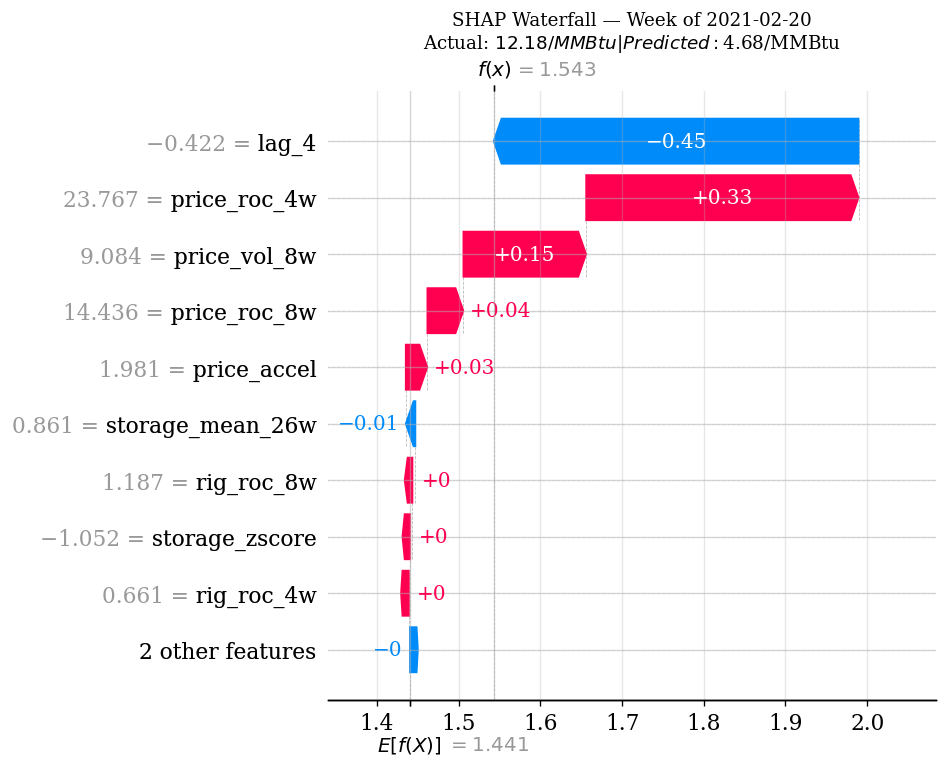

In [113]:
shap.initjs()

# e.g. - polar vortex
target_date = pd.Timestamp('2021-02-20')  # polar vortex week
volatile_dates = final_data['X_volatile_sc'].index

# finding closest available date to target
closest_idx = (volatile_dates - target_date).to_series().abs().argmin()
sample_idx  = closest_idx

print(f"Selected date: {volatile_dates[sample_idx].date()}")
print(f"Target was:    {target_date.date()}")

# clears prior plots (can remove if multiple plots want to be plotted simultaneously)
plt.close('all')

# SHAP explainer on the trimmed, final model
explainer = shap.TreeExplainer(final_xgb_clean)
shap_values_sample = explainer.shap_values(
    final_data['X_volatile_sc'].iloc[[sample_idx]]
)

actual_log    = final_data['y_volatile'].iloc[sample_idx]
predicted_log = final_xgb_clean.predict(
    final_data['X_volatile_sc'].iloc[[sample_idx]]
)[0]
actual_price    = np.exp(actual_log)
predicted_price = np.exp(predicted_log)
shap_values_full = explainer(final_data['X_volatile_sc'])

fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_values_full[sample_idx], max_display=10, show=False)

plt.title(
    f"SHAP Waterfall — Week of {volatile_dates[sample_idx].date()}\n"
    f"Actual: ${actual_price:.2f}/MMBtu | Predicted: ${predicted_price:.2f}/MMBtu",
    fontsize=11
)
plt.tight_layout()
plt.savefig('shap_waterfall_polar_vortex.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating computational cost

In [114]:
def import_platform_info():
    mem_gb = psutil.virtual_memory().total / 1024**3
    return (f"CPU: {platform.processor()} | "
            f"Cores: {psutil.cpu_count(logical=False)} physical | "
            f"RAM: {mem_gb:.1f} GB | "
            f"OS: {platform.system()} {platform.release()}")

def benchmark_model(model_fn, X_train, y_train, n_runs=5):
    """
    Measure training time and peak memory over multiple runs.
    n_runs=5 gives a stable mean and std.
    """
    times        = []
    peak_memories = []

    for run in range(n_runs):
        tracemalloc.start()
        start = time.perf_counter()

        model = model_fn()
        model.fit(X_train, y_train)

        elapsed       = time.perf_counter() - start
        _, peak       = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        times.append(elapsed)
        peak_memories.append(peak / 1024 / 1024)  # bytes → MB
        print(f"  Run {run+1}: {elapsed:.3f}s | {peak/1024/1024:.1f} MB")

    return {
        'mean_time_sec':  round(np.mean(times),  4),
        'std_time_sec':   round(np.std(times),   4),
        'mean_peak_mb':   round(np.mean(peak_memories), 2),
        'std_peak_mb':    round(np.std(peak_memories),  2)
    }

# benchmark XGBoost (final trimmed model)
print("Benchmarking XGBoost...")
xgb_bench = benchmark_model(
    lambda: XGBRegressor(**xgb_params_volatile_tuned),
    final_data['X_train_sc'],
    final_data['y_train']
)

# benchmark RandomForest
print("\nBenchmarking RandomForest...")
rf_bench = benchmark_model(
    lambda: RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1),
    final_data['X_train_sc'],
    final_data['y_train']
)

# benchmark Ridge (baseline)
print("\nBenchmarking Ridge...")
ridge_bench = benchmark_model(
    lambda: RidgeCV(
        alphas=[0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000],
        cv=tscv,
        scoring='neg_mean_squared_error'
    ),
    baseline_data['X_train_sc'],
    baseline_data['y_train']
)

# summary table
print(f"\n{'=' * 72}")
print("Computational Cost Benchmark")
print(f"{'=' * 72}")
print(f"{'Model':<30} {'Train Time (s)':>16} {'Peak Memory (MB)':>18}")
print("-" * 66)
for name, bench in [
    ('Ridge (baseline)',     ridge_bench),
    ('RandomForest',         rf_bench),
    ('XGBoost (final)',      xgb_bench),
]:
    print(f"{name:<30} "
          f"{bench['mean_time_sec']:>8.4f} ± {bench['std_time_sec']:<6.4f} "
          f"{bench['mean_peak_mb']:>10.2f} ± {bench['std_peak_mb']:.2f}")

# du et al. reference — from their published paper 
print(f"\n{'Du et al. FS-CDO-CNN-LSTM&SVR':<30} {'Not reported':>16} {'Not reported':>18}")
print(f"{'(estimated from paper)':>30} {'Hours (GPU)':>16} {'GB-scale':>18}")

print(f"\nHardware context: {import_platform_info()}")

Benchmarking XGBoost...
  Run 1: 0.469s | 0.6 MB
  Run 2: 0.487s | 0.6 MB
  Run 3: 0.416s | 0.6 MB
  Run 4: 0.386s | 0.6 MB
  Run 5: 0.432s | 0.6 MB

Benchmarking RandomForest...
  Run 1: 5.902s | 0.9 MB
  Run 2: 5.908s | 0.9 MB
  Run 3: 5.976s | 0.9 MB
  Run 4: 5.971s | 0.9 MB
  Run 5: 5.963s | 0.9 MB

Benchmarking Ridge...
  Run 1: 0.274s | 0.1 MB
  Run 2: 0.275s | 0.1 MB
  Run 3: 0.267s | 0.1 MB
  Run 4: 0.267s | 0.1 MB
  Run 5: 0.267s | 0.1 MB

Computational Cost Benchmark
Model                            Train Time (s)   Peak Memory (MB)
------------------------------------------------------------------
Ridge (baseline)                 0.2701 ± 0.0039       0.14 ± 0.00
RandomForest                     5.9440 ± 0.0322       0.92 ± 0.01
XGBoost (final)                  0.4381 ± 0.0362       0.59 ± 0.01

Du et al. FS-CDO-CNN-LSTM&SVR      Not reported       Not reported
        (estimated from paper)      Hours (GPU)           GB-scale

Hardware context: CPU: x86_64 | Cores: 2 physic

Statistical significance test - Diebold-Mariano test will be conducted to substantiate comparative performances

In [115]:
# Diebold-Mariano test function 
def diebold_mariano_test(actual, pred1, pred2, h=1):
    e1 = actual - pred1
    e2 = actual - pred2
    d  = e1**2 - e2**2

    n     = len(d)
    d_bar = np.mean(d)

    gamma_0 = np.var(d, ddof=1)
    dm_stat = d_bar / np.sqrt(gamma_0 / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return {
        'DM_statistic': round(dm_stat, 4),
        'p_value':      round(p_value, 4),
        'significant':  p_value < 0.05
    }

# fit and predict all models on ensemble_data_v2 
actual_volatile = np.exp(ensemble_data_v2['y_volatile'].values)
actual_stable   = np.exp(ensemble_data_v2['y_stable'].values)

# XGBoost
xgb_model = XGBRegressor(**xgb_params_volatile_tuned)
xgb_model.fit(ensemble_data_v2['X_train_sc'], ensemble_data_v2['y_train'])
pred_xgb_volatile = np.exp(xgb_model.predict(ensemble_data_v2['X_volatile_sc']))
pred_xgb_stable   = np.exp(xgb_model.predict(ensemble_data_v2['X_stable_sc']))

# RandomForest
rf_model = RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1)
rf_model.fit(ensemble_data_v2['X_train_sc'], ensemble_data_v2['y_train'])
pred_rf_volatile = np.exp(rf_model.predict(ensemble_data_v2['X_volatile_sc']))
pred_rf_stable   = np.exp(rf_model.predict(ensemble_data_v2['X_stable_sc']))

# Ridge — refit on ensemble_data_v2 features for fair comparison
ridge_model = RidgeCV(
    alphas=[0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000],
    cv=tscv,
    scoring='neg_mean_squared_error'
)
ridge_model.fit(ensemble_data_v2['X_train_sc'], ensemble_data_v2['y_train'])
pred_ridge_volatile = np.exp(ridge_model.predict(ensemble_data_v2['X_volatile_sc']))
pred_ridge_stable   = np.exp(ridge_model.predict(ensemble_data_v2['X_stable_sc']))

# enhanced stacking — pull from already-computed results
pred_stack_volatile = np.exp(enhanced_results['pred_volatile_log'])
pred_stack_stable   = np.exp(enhanced_results['pred_stable_log'])

# format: (label, pred_model1, pred_model2, actual)
# pred_model1 is the model being tested as superior to pred_model2
# negative DM stat = model1 has lower loss = model1 is better

comparisons_volatile = [
    ("XGBoost vs Ridge",         pred_xgb_volatile,   pred_ridge_volatile),
    ("XGBoost vs RandomForest",  pred_xgb_volatile,   pred_rf_volatile),
    ("XGBoost vs Stack",         pred_xgb_volatile,   pred_stack_volatile),
    ("Stack vs Ridge",           pred_stack_volatile, pred_ridge_volatile),
    ("Stack vs RandomForest",    pred_stack_volatile, pred_rf_volatile),
    ("RandomForest vs Ridge",    pred_rf_volatile,    pred_ridge_volatile),
]

comparisons_stable = [
    ("XGBoost vs Ridge",         pred_xgb_stable,   pred_ridge_stable),
    ("XGBoost vs RandomForest",  pred_xgb_stable,   pred_rf_stable),
    ("XGBoost vs Stack",         pred_xgb_stable,   pred_stack_stable),
    ("Stack vs Ridge",           pred_stack_stable, pred_ridge_stable),
    ("Stack vs RandomForest",    pred_stack_stable, pred_rf_stable),
    ("RandomForest vs Ridge",    pred_rf_stable,    pred_ridge_stable),
]

# running DM tests iteratively
def run_dm_suite(comparisons, actual, window_label):
    print(f"\n{'=' * 65}")
    print(f"Diebold-Mariano Tests — {window_label}")
    print(f"{'=' * 65}")
    print(f"{'Comparison':<30} {'DM Stat':>10} {'p-value':>10} {'Sig':>6}")
    print("-" * 65)

    results = {}
    for label, p1, p2 in comparisons:
        dm = diebold_mariano_test(actual, p1, p2)
        sig_str = '✓' if dm['significant'] else '✗'
        print(f"{label:<30} {dm['DM_statistic']:>10.4f} "
              f"{dm['p_value']:>10.4f} {sig_str:>6}")
        results[label] = dm

    return results

dm_volatile = run_dm_suite(comparisons_volatile, actual_volatile,
                           "Volatile Window 2019–2024")
dm_stable   = run_dm_suite(comparisons_stable,   actual_stable,
                           "Stable Window 2015–2019")

# significant tests only**
print(f"\n{'=' * 65}")
print("Statistically Significant Results (p < 0.05)")
print(f"{'=' * 65}")

for window_label, results in [
    ("Volatile", dm_volatile),
    ("Stable",   dm_stable)
]:
    sig = {k: v for k, v in results.items() if v['significant']}
    print(f"\n{window_label} window ({len(sig)} significant):")
    for label, dm in sig.items():
        direction = "Model 1 better" if dm['DM_statistic'] < 0 else "Model 2 better"
        print(f"  {label:<30} p={dm['p_value']}  ({direction})")


Diebold-Mariano Tests — Volatile Window 2019–2024
Comparison                        DM Stat    p-value    Sig
-----------------------------------------------------------------
XGBoost vs Ridge                  -1.0845     0.2782      ✗
XGBoost vs RandomForest           -2.3179     0.0205      ✓
XGBoost vs Stack                  -5.2339     0.0000      ✓
Stack vs Ridge                    -0.9196     0.3578      ✗
Stack vs RandomForest              2.6549     0.0079      ✓
RandomForest vs Ridge             -1.0223     0.3066      ✗

Diebold-Mariano Tests — Stable Window 2015–2019
Comparison                        DM Stat    p-value    Sig
-----------------------------------------------------------------
XGBoost vs Ridge                  -8.4543     0.0000      ✓
XGBoost vs RandomForest           -2.0889     0.0367      ✓
XGBoost vs Stack                  -3.9606     0.0001      ✓
Stack vs Ridge                    -0.2151     0.8297      ✗
Stack vs RandomForest              4.1756     0.